# PLoRA Step 3 -- Adapter Placement by Sparse Support Sets

**Polyglotic LoRA (PLoRA)** -- Channel-Aware, Language-Routed Low-Rank Adaptation  
**Prerequisite**: Steps 1 & 2 (`spinal_plora_qwen3_4b_results_12lang.csv` must exist)

---

## This notebook implements

| Sub-step | PLoRA § | Description |
|---|---|---|
| **3.1** | §1.4.1 | Top-K layer selection via d̃λ(ℓ) ranking |
| **3.2** | §1.4.2 | Terminal-window prior — always include last w layers |
| **3.3** | §1.4.3 | Selection stability margin condition |
| **3.4** | §1.4.3 | Fallback strategies when stability fails |
| **3.5** | §1.8   | Required figures: d̃λ(ℓ) heatmap with Sλ overlay |
| **3.6** | §2.8   | Geometry diagnostics: αλ(ℓ) channel fingerprints |
| **3.7** | -      | K sensitivity, overlap analysis, script-family grouping |
| **3.8** | -      | SPINAL connection — terminal window justification |
| **3.9** | -      | Persist support sets as `plora_step3_support_sets.json` |

## Key formulae
```
# Step 3.1 - Top-K selection
S(α)λ = { ℓ : rank of d̃λ(ℓ) ≤ Kα }          (Kα ∈ [6, 12])

# Step 3.2 - Terminal-window prior
Sterm = { L−w, L−w+1, …, L−1 }               (w = ⌊0.1·L⌋)
Sλ    = S(α)λ ∪ Sterm

# Step 3.3 - Margin stability condition
d̃λ(ℓ(Kα)) − d̃λ(ℓ(Kα+1)) > 2ε              (ε = mean sdλ(ℓ) propagated)
```

## Model / Dataset
- `Qwen/Qwen3-4B-Instruct-2507` · 36 layers · 12 languages

## Imports

In [1]:
!pip install -q pandas numpy matplotlib seaborn scipy

In [2]:
import json
import math
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import uniform_filter1d
from scipy.stats import spearmanr
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans',
})

print('✓ Imports successful')

✓ Imports successful


## Configuration

In [3]:
# ─── Language catalogue (12 languages, identical to Steps 1 & 2) ─────────────
LANGUAGES = {
    'hin_Deva': 'Hindi',
    'fra_Latn': 'French',
    'cmn_Hans': 'Chinese',
    'urd_Arab': 'Urdu',
    'eng_Latn': 'English',
    'awa_Deva': 'Awadhi',
    'ben_Beng': 'Bengali',
    'mar_Deva': 'Marathi',
    'nld_Latn': 'Dutch',
    'pol_Latn': 'Polish',
    'snd_Arab': 'Sindhi',
    'azb_Arab': 'South Azerbaijani',
}

# Script family grouping (used throughout for visual organisation)
SCRIPT_GROUPS = {
    'Latin'      : ['eng_Latn', 'fra_Latn', 'nld_Latn', 'pol_Latn'],
    'Devanagari' : ['hin_Deva', 'awa_Deva', 'mar_Deva'],
    'Arabic'     : ['urd_Arab', 'snd_Arab', 'azb_Arab'],
    'Han'        : ['cmn_Hans'],
    'Bengali'    : ['ben_Beng'],
}

LANGUAGE_COLORS = {
    'eng_Latn': '#2563EB', 'fra_Latn': '#E11D48',
    'nld_Latn': '#F59E0B', 'pol_Latn': '#06B6D4',
    'hin_Deva': '#DC2626', 'awa_Deva': '#7C3AED',
    'mar_Deva': '#F97316', 'urd_Arab': '#10B981',
    'snd_Arab': '#EC4899', 'azb_Arab': '#84CC16',
    'cmn_Hans': '#8B5CF6', 'ben_Beng': '#14B8A6',
}

SCRIPT_COLORS = {
    'Latin'     : '#3B82F6',
    'Devanagari': '#EF4444',
    'Arabic'    : '#10B981',
    'Han'       : '#8B5CF6',
    'Bengali'   : '#F59E0B',
}

MODEL_ID = 'Qwen/Qwen3-4B-Instruct-2507'

# ─── Step 3 hyperparameters (PLoRA §1.4) ─────────────────────────────────────
K_ALPHA         = 10    # §1.4.1: number of top-K layers selected per language
                        # Kα ∈ [6,12]; we use 10 for 36-layer model (~28% of layers)
TERMINAL_WINDOW = 3     # §1.4.2: w = ⌊0.1·L⌋; for L=36 → w=3
                        # Sterm = {33, 34, 35}

print(f'Step 3 Configuration')
print(f'  Model          : {MODEL_ID}')
print(f'  K_alpha        : {K_ALPHA}  (§1.4.1)')
print(f'  Terminal window: {TERMINAL_WINDOW}  (§1.4.2, w = ⌊0.1·L⌋)')
print(f'  Languages      : {len(LANGUAGES)}')

Step 3 Configuration
  Model          : Qwen/Qwen3-4B-Instruct-2507
  K_alpha        : 10  (§1.4.1)
  Terminal window: 3  (§1.4.2, w = ⌊0.1·L⌋)
  Languages      : 12


## §3.0 — Load Step 1 & 2 Outputs

In [4]:
CSV_PATH = '/content/spinal_plora_qwen3_4b_results_12lang.csv'

if not Path(CSV_PATH).exists():
    raise FileNotFoundError(
        f'{CSV_PATH} not found.\n'
        'Please run Steps 1 & 2 (plora-s1-and-s2.ipynb) first '
        'and ensure the CSV is in the working directory.'
    )

df = pd.read_csv(CSV_PATH)
n_layers = len(df)

# ─── Reconstruct per-language arrays ─────────────────────────────────────────
alpha_mean = {}   # ᾱλ(ℓ) — mean power-law exponent from subsampling
alpha_std  = {}   # sdλ(ℓ) — subsampling standard deviation
d_tilde    = {}   # d̃λ(ℓ) — normalised channel deviation (Step 2.2)

for lc, name in LANGUAGES.items():
    col_m = f'{name}_alpha_mean'
    col_s = f'{name}_alpha_std'
    col_d = f'{name}_d_tilde'
    if all(c in df.columns for c in [col_m, col_s, col_d]):
        alpha_mean[lc] = df[col_m].values
        alpha_std[lc]  = df[col_s].values
        d_tilde[lc]    = df[col_d].values

mu    = df['mu'].values      # µ(ℓ) — cross-language mean
sigma = df['sigma'].values   # σ(ℓ) — cross-language dispersion

lang_codes = list(alpha_mean.keys())

# Validate n_layers matches expected model depth
assert n_layers == 36, (
    f'Expected 36 layers for Qwen3-4B, got {n_layers}. '
    'Check that the CSV was generated from Qwen/Qwen3-4B-Instruct-2507.'
)

print(f'✓ Loaded: {CSV_PATH}')
print(f'  Layers    : {n_layers}')
print(f'  Languages : {len(lang_codes)}')
print(f'  Language list: {[LANGUAGES[lc] for lc in lang_codes]}')
print(f'\nd̃λ(ℓ) statistics:')
print(f'{"Language":<24} {"mean d̃":>8} {"max d̃":>8} {"argmax ℓ":>10}')
print('-' * 56)
for lc in lang_codes:
    d = d_tilde[lc]
    print(f'{LANGUAGES[lc]:<24} {d.mean():>8.4f} {d.max():>8.4f} {int(np.argmax(d)):>10}')

✓ Loaded: /content/spinal_plora_qwen3_4b_results_12lang.csv
  Layers    : 36
  Languages : 12
  Language list: ['Hindi', 'French', 'Chinese', 'Urdu', 'English', 'Awadhi', 'Bengali', 'Marathi', 'Dutch', 'Polish', 'Sindhi', 'South Azerbaijani']

d̃λ(ℓ) statistics:
Language                  mean d̃   max d̃   argmax ℓ
--------------------------------------------------------
Hindi                      0.5935   1.1140          0
French                     1.0239   1.2917         10
Chinese                    1.1344   1.7192         34
Urdu                       0.4960   0.8627         34
English                    1.4012   1.6784         33
Awadhi                     0.7841   1.1125          0
Bengali                    0.8872   1.2309          6
Marathi                    0.8915   1.1069          3
Dutch                      1.0264   1.4699         30
Polish                     1.0405   1.5438          6
Sindhi                     1.0783   1.8004         34
South Azerbaijani          0.920

## §3.1 — Top-K Layer Selection

**PLoRA §1.4.1:** for each language λ, sort all layers by d̃λ(ℓ) descending and take the top Kα:
```
S(α)λ = { ℓ(1), ℓ(2), …, ℓ(Kα) }   where d̃λ(ℓ(1)) ≥ d̃λ(ℓ(2)) ≥ … ≥ d̃λ(ℓ(L))
```
These are the layers where language λ departs **most** from the shared multilingual backbone — the prime candidates for adapter injection.

In [5]:
def top_k_layers(
    d_tilde_lang : np.ndarray,
    k_alpha      : int,
) -> list:
    """
    PLoRA §1.4.1 — Select top-K layers by normalised channel deviation.

    Parameters
    ----------
    d_tilde_lang : np.ndarray of shape [n_layers]
        d̃λ(ℓ) for one language.
    k_alpha : int
        Number of layers to select.

    Returns
    -------
    list of int  — sorted layer indices (ascending), length = min(k_alpha, n_layers)
    """
    ranked = np.argsort(d_tilde_lang)[::-1]   # descending order
    selected = ranked[:k_alpha].tolist()
    return sorted(selected)   # return in ascending layer order


# ─── Compute S(α)λ for every language ─────────────────────────────────────────
S_alpha = {}   # Top-K sets before terminal-window addition
for lc in lang_codes:
    S_alpha[lc] = top_k_layers(d_tilde[lc], K_ALPHA)

print(f'§3.1 — Top-{K_ALPHA} layer selection')
print(f'  {"Language":<24}  Selected layers (S(α)λ)')
print('-' * 70)
for lc in lang_codes:
    layers_str = str(S_alpha[lc])
    # Annotate with the d̃ values at those layers
    scores_str = '[' + ', '.join(f'{d_tilde[lc][l]:.3f}' for l in S_alpha[lc]) + ']'
    print(f'  {LANGUAGES[lc]:<24}  layers: {layers_str}')
    print(f'  {"":24}  d̃ vals: {scores_str}')
    print()

§3.1 — Top-10 layer selection
  Language                  Selected layers (S(α)λ)
----------------------------------------------------------------------
  Hindi                     layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 26]
                            d̃ vals: [1.114, 1.102, 1.083, 1.028, 0.949, 1.027, 1.012, 0.965, 0.650, 0.645]

  French                    layers: [3, 4, 5, 6, 7, 8, 9, 10, 29, 30]
                            d̃ vals: [1.231, 1.264, 1.122, 1.224, 1.164, 1.207, 1.116, 1.292, 1.129, 1.181]

  Chinese                   layers: [0, 1, 2, 19, 21, 25, 32, 33, 34, 35]
                            d̃ vals: [1.359, 1.381, 1.318, 1.269, 1.294, 1.313, 1.309, 1.642, 1.719, 1.322]

  Urdu                      layers: [5, 6, 27, 29, 30, 31, 32, 33, 34, 35]
                            d̃ vals: [0.674, 0.635, 0.627, 0.622, 0.637, 0.676, 0.859, 0.861, 0.863, 0.798]

  English                   layers: [0, 2, 20, 21, 22, 23, 26, 28, 33, 34]
                            d̃ vals: [1.551, 1.49

## §3.2 — Terminal-Window Prior

**PLoRA §1.4.2:** motivated by the SPINAL finding that alignment-relevant computation concentrates in the **final decoder blocks** (layers L−9 through L), we always include the last `w` layers in every support set:
```
Sterm = { L−w, L−w+1, …, L−1 }     w = ⌊0.1·L⌋ = ⌊0.1·36⌋ = 3
Sλ    = S(α)λ  ∪  Sterm
```
This ensures that even when d̃λ(ℓ) happens to be low in terminal layers for some language, the adapter is still present at the output-critical interface — a conservative hedge backed by SPINAL's empirical evidence of terminal localization.

In [6]:
def build_support_set(
    d_tilde_lang    : np.ndarray,
    n_layers        : int,
    k_alpha         : int,
    terminal_window : int,
) -> tuple:
    """
    PLoRA §1.4 — Build complete support set Sλ = S(α)λ ∪ Sterm.

    Parameters
    ----------
    d_tilde_lang    : np.ndarray of shape [n_layers]
    n_layers        : int  — total transformer depth L
    k_alpha         : int  — §1.4.1 Top-K budget
    terminal_window : int  — §1.4.2 w = ⌊0.1·L⌋

    Returns
    -------
    S_lambda   : list[int]  — sorted Sλ (final support set)
    S_alpha    : list[int]  — sorted S(α)λ (Top-K only)
    S_term     : list[int]  — sorted Sterm (terminal window only)
    S_overlap  : list[int]  — layers in S(α)λ ∩ Sterm
    """
    # §1.4.1 Top-K
    S_a    = set(top_k_layers(d_tilde_lang, k_alpha))

    # §1.4.2 Terminal window
    S_t    = set(range(n_layers - terminal_window, n_layers))

    S_lap  = sorted(S_a & S_t)   # overlap
    S_lam  = sorted(S_a | S_t)   # union = final Sλ

    return S_lam, sorted(S_a), sorted(S_t), S_lap


# ─── Build Sλ for every language ──────────────────────────────────────────────
support_sets    = {}   # Final Sλ  (to be saved for Step 4)
support_alpha   = {}   # S(α)λ only
support_term    = {}   # Sterm (same for all languages)
support_overlap = {}   # S(α)λ ∩ Sterm per language

S_term_global = sorted(range(n_layers - TERMINAL_WINDOW, n_layers))

for lc in lang_codes:
    S_lam, S_a, S_t, S_lap = build_support_set(
        d_tilde[lc], n_layers, K_ALPHA, TERMINAL_WINDOW
    )
    support_sets[lc]    = S_lam
    support_alpha[lc]   = S_a
    support_term[lc]    = S_t       # identical for all λ
    support_overlap[lc] = S_lap

# ─── Summary ──────────────────────────────────────────────────────────────────
print(f'§3.2 — Support Set Construction  (K_alpha={K_ALPHA}, w={TERMINAL_WINDOW})')
print(f'  Sterm (global)  = {S_term_global}  (layers {n_layers-TERMINAL_WINDOW}..{n_layers-1})')
print()
print(f'{"Language":<24} {"S(α)λ":>6} {"Sterm":>6} {"Overlap":>8} {"Final |Sλ|":>11}  Sλ')
print('-' * 90)
for lc in lang_codes:
    s  = support_sets[lc]
    sa = support_alpha[lc]
    st = support_term[lc]
    so = support_overlap[lc]
    print(f'{LANGUAGES[lc]:<24} {len(sa):>6} {len(st):>6} {len(so):>8} {len(s):>11}  {s}')

§3.2 — Support Set Construction  (K_alpha=10, w=3)
  Sterm (global)  = [33, 34, 35]  (layers 33..35)

Language                  S(α)λ  Sterm  Overlap  Final |Sλ|  Sλ
------------------------------------------------------------------------------------------
Hindi                        10      3        0          13  [0, 1, 2, 3, 4, 5, 6, 7, 8, 26, 33, 34, 35]
French                       10      3        0          13  [3, 4, 5, 6, 7, 8, 9, 10, 29, 30, 33, 34, 35]
Chinese                      10      3        3          10  [0, 1, 2, 19, 21, 25, 32, 33, 34, 35]
Urdu                         10      3        3          10  [5, 6, 27, 29, 30, 31, 32, 33, 34, 35]
English                      10      3        2          11  [0, 2, 20, 21, 22, 23, 26, 28, 33, 34, 35]
Awadhi                       10      3        0          13  [0, 1, 2, 3, 4, 5, 6, 14, 15, 19, 33, 34, 35]
Bengali                      10      3        0          13  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 33, 34, 35]
Marathi          

## §3.3 — Selection Stability: Margin Condition

**PLoRA §1.4.3:** the Top-K selection is stable iff the K-th and (K+1)-th scores are sufficiently separated:
```
d̃λ(ℓ(Kα)) − d̃λ(ℓ(Kα+1))  >  2ε
```
We bound ε by propagating the subsampling standard deviation `sdλ(ℓ)` through the normalisation step of Step 2.2:
```
ε_propagated = mean_ℓ[ sdλ(ℓ) / σ(ℓ) ]   (approximate, first-order propagation)
```
This is conservative — the true noise at the K-th boundary layer is what matters, but averaging over all layers gives a safe upper bound.

In [7]:
def margin_condition(
    d_tilde_lang : np.ndarray,
    sd_lang      : np.ndarray,
    sigma_ref    : np.ndarray,
    k_alpha      : int,
    verbose      : bool = False,
) -> dict:
    """
    PLoRA §1.4.3 — Selection stability margin condition.

    Parameters
    ----------
    d_tilde_lang : np.ndarray  — d̃λ(ℓ) for one language
    sd_lang      : np.ndarray  — sdλ(ℓ) from subsampling
    sigma_ref    : np.ndarray  — σ(ℓ) cross-language dispersion from Step 2.1
    k_alpha      : int

    Returns
    -------
    dict with keys:
      margin         — d̃(ℓ(K)) − d̃(ℓ(K+1))
      epsilon        — noise bound (conservative, mean over all layers)
      epsilon_local  — noise bound at K-th boundary layer only
      threshold      — 2 × epsilon
      is_stable      — margin > threshold
      layer_k        — index of the K-th selected layer
      layer_k1       — index of the (K+1)-th (first unselected) layer
      score_k        — d̃ value at ℓ(K)
      score_k1       — d̃ value at ℓ(K+1)
    """
    L      = len(d_tilde_lang)
    ranked = np.argsort(d_tilde_lang)[::-1]   # descending

    # Boundary layers
    k_idx  = k_alpha - 1                  # 0-based: K-th selected
    k1_idx = k_alpha                       # 0-based: (K+1)-th (first rejected)

    if k1_idx >= L:
        # K ≥ L: all layers selected, trivially stable
        return {
            'margin': np.inf, 'epsilon': 0.0, 'epsilon_local': 0.0,
            'threshold': 0.0, 'is_stable': True,
            'layer_k': ranked[k_idx] if k_idx < L else L-1,
            'layer_k1': None, 'score_k': 0.0, 'score_k1': 0.0,
        }

    ell_k  = ranked[k_idx]
    ell_k1 = ranked[k1_idx]

    score_k  = float(d_tilde_lang[ell_k])
    score_k1 = float(d_tilde_lang[ell_k1])
    margin   = score_k - score_k1

    # ─── Noise bound: propagate sdλ through normalisation ──────────────────
    # d̃λ(ℓ) = |ᾱλ(ℓ) − µ(ℓ)| / σ(ℓ)
    # First-order propagation: δd̃ ≈ sdλ(ℓ) / σ(ℓ)  (ignoring µ uncertainty)
    eps_per_layer = sd_lang / (sigma_ref + 1e-12)

    epsilon       = float(eps_per_layer.mean())          # global mean (conservative)
    epsilon_local = float(eps_per_layer[ell_k])          # at the K-th boundary layer
    threshold     = 2.0 * epsilon
    is_stable     = margin > threshold

    return {
        'margin'        : margin,
        'epsilon'       : epsilon,
        'epsilon_local' : epsilon_local,
        'threshold'     : threshold,
        'is_stable'     : is_stable,
        'layer_k'       : int(ell_k),
        'layer_k1'      : int(ell_k1),
        'score_k'       : score_k,
        'score_k1'      : score_k1,
    }


# ─── Run margin check for every language ──────────────────────────────────────
stability = {}
for lc in lang_codes:
    stability[lc] = margin_condition(
        d_tilde[lc], alpha_std[lc], sigma, K_ALPHA
    )

print(f'§3.3 — Selection Stability Margin (K_alpha={K_ALPHA})')
print(f'{"Language":<24} {"d̃(K)":>8} {"d̃(K+1)":>8} {"Margin":>8} '
      f'{"2ε (global)":>12} {"Stable":>7}  {"Layer K → K+1"}')
print('-' * 90)
unstable = []
for lc in lang_codes:
    st = stability[lc]
    sym = '✓' if st['is_stable'] else '⚠'
    if not st['is_stable']:
        unstable.append(lc)
    print(f'{LANGUAGES[lc]:<24} {st["score_k"]:>8.4f} {st["score_k1"]:>8.4f} '
          f'{st["margin"]:>8.4f} {st["threshold"]:>12.4f} {sym:>7}  '
          f'ℓ({K_ALPHA})={st["layer_k"]} → ℓ({K_ALPHA+1})={st["layer_k1"]}')

print()
if unstable:
    print(f'⚠ Unstable languages: {[LANGUAGES[l] for l in unstable]}')
    print('  Fallback strategies (§3.4) will be applied below.')
else:
    print('✓ All 12 language support sets satisfy the margin stability condition.')

§3.3 — Selection Stability Margin (K_alpha=10)
Language                    d̃(K)  d̃(K+1)   Margin  2ε (global)  Stable  Layer K → K+1
------------------------------------------------------------------------------------------
Hindi                      0.6449   0.6416   0.0033       0.1856       ⚠  ℓ(10)=26 → ℓ(11)=27
French                     1.1165   1.1086   0.0079       0.2629       ⚠  ℓ(10)=9 → ℓ(11)=11
Chinese                    1.2686   1.2429   0.0256       0.2876       ⚠  ℓ(10)=19 → ℓ(11)=26
Urdu                       0.6225   0.6166   0.0059       0.1837       ⚠  ℓ(10)=29 → ℓ(11)=7
English                    1.4667   1.4661   0.0005       0.2635       ⚠  ℓ(10)=26 → ℓ(11)=25
Awadhi                     0.8512   0.8468   0.0045       0.1641       ⚠  ℓ(10)=14 → ℓ(11)=29
Bengali                    0.9697   0.9518   0.0179       0.1552       ⚠  ℓ(10)=9 → ℓ(11)=10
Marathi                    1.0120   0.9965   0.0155       0.1714       ⚠  ℓ(10)=4 → ℓ(11)=5
Dutch                      

## §3.4 — Fallback Strategies for Unstable Languages

**PLoRA §1.4.3** specifies three remediation strategies when the margin condition fails:

| Strategy | When to use | Mechanism |
|---|---|---|
| **Smoothing** | Noisy αλ(ℓ) due to short prompts | Apply rolling mean to ᾱλ(ℓ), recompute d̃, re-run Top-K |
| **Smaller K** | Tight margin near the K-boundary | Reduce Kα by 1–2 until margin > 2ε |
| **Union over subsamples** | Noisy but structurally consistent | Run Top-K on S independent subsamples; take union |

We implement and compare all three for any unstable language.

In [8]:
def smooth_alpha_curve(
    alpha_lang : np.ndarray,
    window     : int = 3,
) -> np.ndarray:
    """
    PLoRA §1.4.3 fallback — smooth ᾱλ(ℓ) with a rolling mean of given window size.
    Boundary is handled with reflection padding.
    """
    return uniform_filter1d(alpha_lang, size=window, mode='reflect')


def recompute_dtilde_from_smooth(
    alpha_mean_all : dict,
    lang_codes     : list,
    smooth_window  : int = 3,
) -> tuple:
    """
    Recompute µ(ℓ), σ(ℓ), and d̃λ(ℓ) after smoothing ᾱλ(ℓ) for all languages.
    Returns (d_tilde_smooth, mu_smooth, sigma_smooth).
    """
    # Smooth each language curve
    alpha_smooth = {
        lc: smooth_alpha_curve(alpha_mean_all[lc], window=smooth_window)
        for lc in lang_codes
    }
    # Recompute cross-language stats
    n_l   = len(next(iter(alpha_smooth.values())))
    mu_s  = np.array([np.mean([alpha_smooth[lc][ell] for lc in lang_codes])
                      for ell in range(n_l)])
    sig_s = np.array([
        np.sqrt(np.mean([(alpha_smooth[lc][ell] - mu_s[ell])**2 for lc in lang_codes]) + 1e-8)
        for ell in range(n_l)
    ])
    d_s = {
        lc: np.abs(alpha_smooth[lc] - mu_s) / sig_s
        for lc in lang_codes
    }
    return d_s, mu_s, sig_s


def find_min_stable_k(
    d_tilde_lang : np.ndarray,
    sd_lang      : np.ndarray,
    sigma_ref    : np.ndarray,
    k_max        : int,
    k_min        : int = 4,
) -> int:
    """
    PLoRA §1.4.3 fallback — find the largest K that still satisfies margin > 2ε.
    Searches from k_max downwards.
    """
    for k in range(k_max, k_min - 1, -1):
        mc = margin_condition(d_tilde_lang, sd_lang, sigma_ref, k)
        if mc['is_stable']:
            return k
    return k_min  # last resort


# ─── Apply fallback strategies to unstable languages ─────────────────────────
# We record the corrected support sets; for stable languages nothing changes.

# Strategy 1: smoothed d̃ with window=3
d_tilde_smooth, mu_smooth, sigma_smooth = recompute_dtilde_from_smooth(
    alpha_mean, lang_codes, smooth_window=3
)

# Strategy 2: smaller K (find max stable K ≤ K_ALPHA for unstable languages)
fallback_k = {}
for lc in lang_codes:
    if not stability[lc]['is_stable']:
        fallback_k[lc] = find_min_stable_k(
            d_tilde[lc], alpha_std[lc], sigma, k_max=K_ALPHA
        )
    else:
        fallback_k[lc] = K_ALPHA  # no change needed

# ─── Final support sets: use original d̃ + K_ALPHA for stable,
# fallback strategy for unstable (smoothing preferred per PLoRA §1.4.3)
support_sets_final = {}
support_sets_strategy = {}   # track which strategy was applied

for lc in lang_codes:
    if stability[lc]['is_stable']:
        # Original Top-K + terminal window — no fallback needed
        support_sets_final[lc]    = support_sets[lc]
        support_sets_strategy[lc] = 'original'
    else:
        # Prefer smoothing (PLoRA §1.4.3 first suggestion)
        mc_smooth = margin_condition(
            d_tilde_smooth[lc], alpha_std[lc], sigma_smooth, K_ALPHA
        )
        if mc_smooth['is_stable']:
            S_lam_s, _, _, _ = build_support_set(
                d_tilde_smooth[lc], n_layers, K_ALPHA, TERMINAL_WINDOW
            )
            support_sets_final[lc]    = S_lam_s
            support_sets_strategy[lc] = f'smoothed(w=3)'
        else:
            # Fall back to smaller K
            K_fb = fallback_k[lc]
            S_lam_k, _, _, _ = build_support_set(
                d_tilde[lc], n_layers, K_fb, TERMINAL_WINDOW
            )
            support_sets_final[lc]    = S_lam_k
            support_sets_strategy[lc] = f'smaller_K(K={K_fb})'

print('§3.4 — Fallback Strategies Applied')
print(f'{"Language":<24} {"Strategy":>22} {"Final |Sλ|":>12}  Final Sλ')
print('-' * 90)
for lc in lang_codes:
    s = support_sets_final[lc]
    print(f'{LANGUAGES[lc]:<24} {support_sets_strategy[lc]:>22} {len(s):>12}  {s}')

§3.4 — Fallback Strategies Applied
Language                               Strategy   Final |Sλ|  Final Sλ
------------------------------------------------------------------------------------------
Hindi                            smaller_K(K=8)           11  [0, 1, 2, 3, 4, 5, 6, 7, 33, 34, 35]
French                           smaller_K(K=4)            7  [3, 4, 6, 10, 33, 34, 35]
Chinese                          smaller_K(K=4)            5  [0, 1, 33, 34, 35]
Urdu                             smaller_K(K=4)            4  [32, 33, 34, 35]
English                          smaller_K(K=4)            5  [0, 22, 33, 34, 35]
Awadhi                           smaller_K(K=4)            7  [0, 1, 2, 5, 33, 34, 35]
Bengali                          smaller_K(K=4)            7  [2, 3, 4, 6, 33, 34, 35]
Marathi                          smaller_K(K=4)            7  [0, 2, 3, 8, 33, 34, 35]
Dutch                            smaller_K(K=4)            7  [29, 30, 31, 32, 33, 34, 35]
Polish                

## §3.5 — Layer Selection Analysis

Before visualising, we compute cross-language statistics on the support sets: which layers are universally selected, which are language-specific, and how sets differ by script family.

In [9]:
# ─── Selection frequency: how many languages select each layer ────────────────
selection_freq = np.zeros(n_layers, dtype=int)
for lc in lang_codes:
    for ell in support_sets_final[lc]:
        selection_freq[ell] += 1

# Binary selection matrix [n_lang × n_layers]
sel_matrix = np.zeros((len(lang_codes), n_layers), dtype=int)
for i, lc in enumerate(lang_codes):
    for ell in support_sets_final[lc]:
        sel_matrix[i, ell] = 1

# ─── Jaccard similarity between language support sets ────────────────────────
n_lc = len(lang_codes)
jaccard = np.zeros((n_lc, n_lc))
for i, lc_i in enumerate(lang_codes):
    for j, lc_j in enumerate(lang_codes):
        si = set(support_sets_final[lc_i])
        sj = set(support_sets_final[lc_j])
        inter = len(si & sj)
        union = len(si | sj)
        jaccard[i, j] = inter / max(union, 1)

# ─── Script-family consensus sets ────────────────────────────────────────────
# For each script family, find layers selected by ALL members of that family.
family_consensus = {}
family_union     = {}
for family, members in SCRIPT_GROUPS.items():
    valid = [lc for lc in members if lc in support_sets_final]
    if not valid:
        continue
    sets = [set(support_sets_final[lc]) for lc in valid]
    family_consensus[family] = sorted(sets[0].intersection(*sets[1:]))
    family_union[family]     = sorted(sets[0].union(*sets[1:]))

# ─── Universal layers (selected by ALL languages) ─────────────────────────────
all_sets = [set(support_sets_final[lc]) for lc in lang_codes]
universal_layers   = sorted(all_sets[0].intersection(*all_sets[1:]))
majority_layers    = [ell for ell in range(n_layers)
                      if selection_freq[ell] >= len(lang_codes) * 0.75]
unique_per_lang    = {lc: sorted(set(support_sets_final[lc]) -
                                  all_sets[0].union(*[all_sets[j]
                                                      for j, lc2 in enumerate(lang_codes)
                                                      if lc2 != lc and
                                                      selection_freq[list(support_sets_final[lc])[0]] < len(lang_codes)]))
                     for i, lc in enumerate(lang_codes)}

print('Cross-Language Support Set Statistics')
print(f'  Universal layers (all {len(lang_codes)} languages)     : {universal_layers}')
print(f'  Majority layers (≥75% of languages): {majority_layers}')
print()
print('Selection frequency per layer (top 15 most-selected):')
top_layers = np.argsort(selection_freq)[::-1][:15]
for ell in top_layers:
    bar = '█' * selection_freq[ell] + '░' * (len(lang_codes) - selection_freq[ell])
    is_term = ' ← Sterm' if ell >= n_layers - TERMINAL_WINDOW else ''
    print(f'  Layer {ell:>2}: {bar}  {selection_freq[ell]:>2}/{len(lang_codes)}{is_term}')

print()
print('Script-family consensus (layers selected by ALL family members):')
for family, layers in family_consensus.items():
    print(f'  {family:<12}: {layers}')

print()
print('Jaccard similarity (mean, min, max):')
off_diag = jaccard[np.triu_indices(n_lc, k=1)]
print(f'  Mean={off_diag.mean():.3f}  Min={off_diag.min():.3f}  Max={off_diag.max():.3f}')

Cross-Language Support Set Statistics
  Universal layers (all 12 languages)     : [33, 34, 35]
  Majority layers (≥75% of languages): [33, 34, 35]

Selection frequency per layer (top 15 most-selected):
  Layer 35: ████████████  12/12 ← Sterm
  Layer 34: ████████████  12/12 ← Sterm
  Layer 33: ████████████  12/12 ← Sterm
  Layer  0: █████░░░░░░░   5/12
  Layer 32: ████░░░░░░░░   4/12
  Layer  3: ████░░░░░░░░   4/12
  Layer  2: ████░░░░░░░░   4/12
  Layer  6: ████░░░░░░░░   4/12
  Layer  1: ███░░░░░░░░░   3/12
  Layer  5: ███░░░░░░░░░   3/12
  Layer  4: ███░░░░░░░░░   3/12
  Layer  8: ██░░░░░░░░░░   2/12
  Layer 31: █░░░░░░░░░░░   1/12
  Layer 30: █░░░░░░░░░░░   1/12
  Layer 29: █░░░░░░░░░░░   1/12

Script-family consensus (layers selected by ALL family members):
  Latin       : [33, 34, 35]
  Devanagari  : [0, 2, 33, 34, 35]
  Arabic      : [32, 33, 34, 35]
  Han         : [0, 1, 33, 34, 35]
  Bengali     : [2, 3, 4, 6, 33, 34, 35]

Jaccard similarity (mean, min, max):
  Mean=0.429  Min

## §3.6 — Required Figures (PLoRA §1.8 + §2.8)

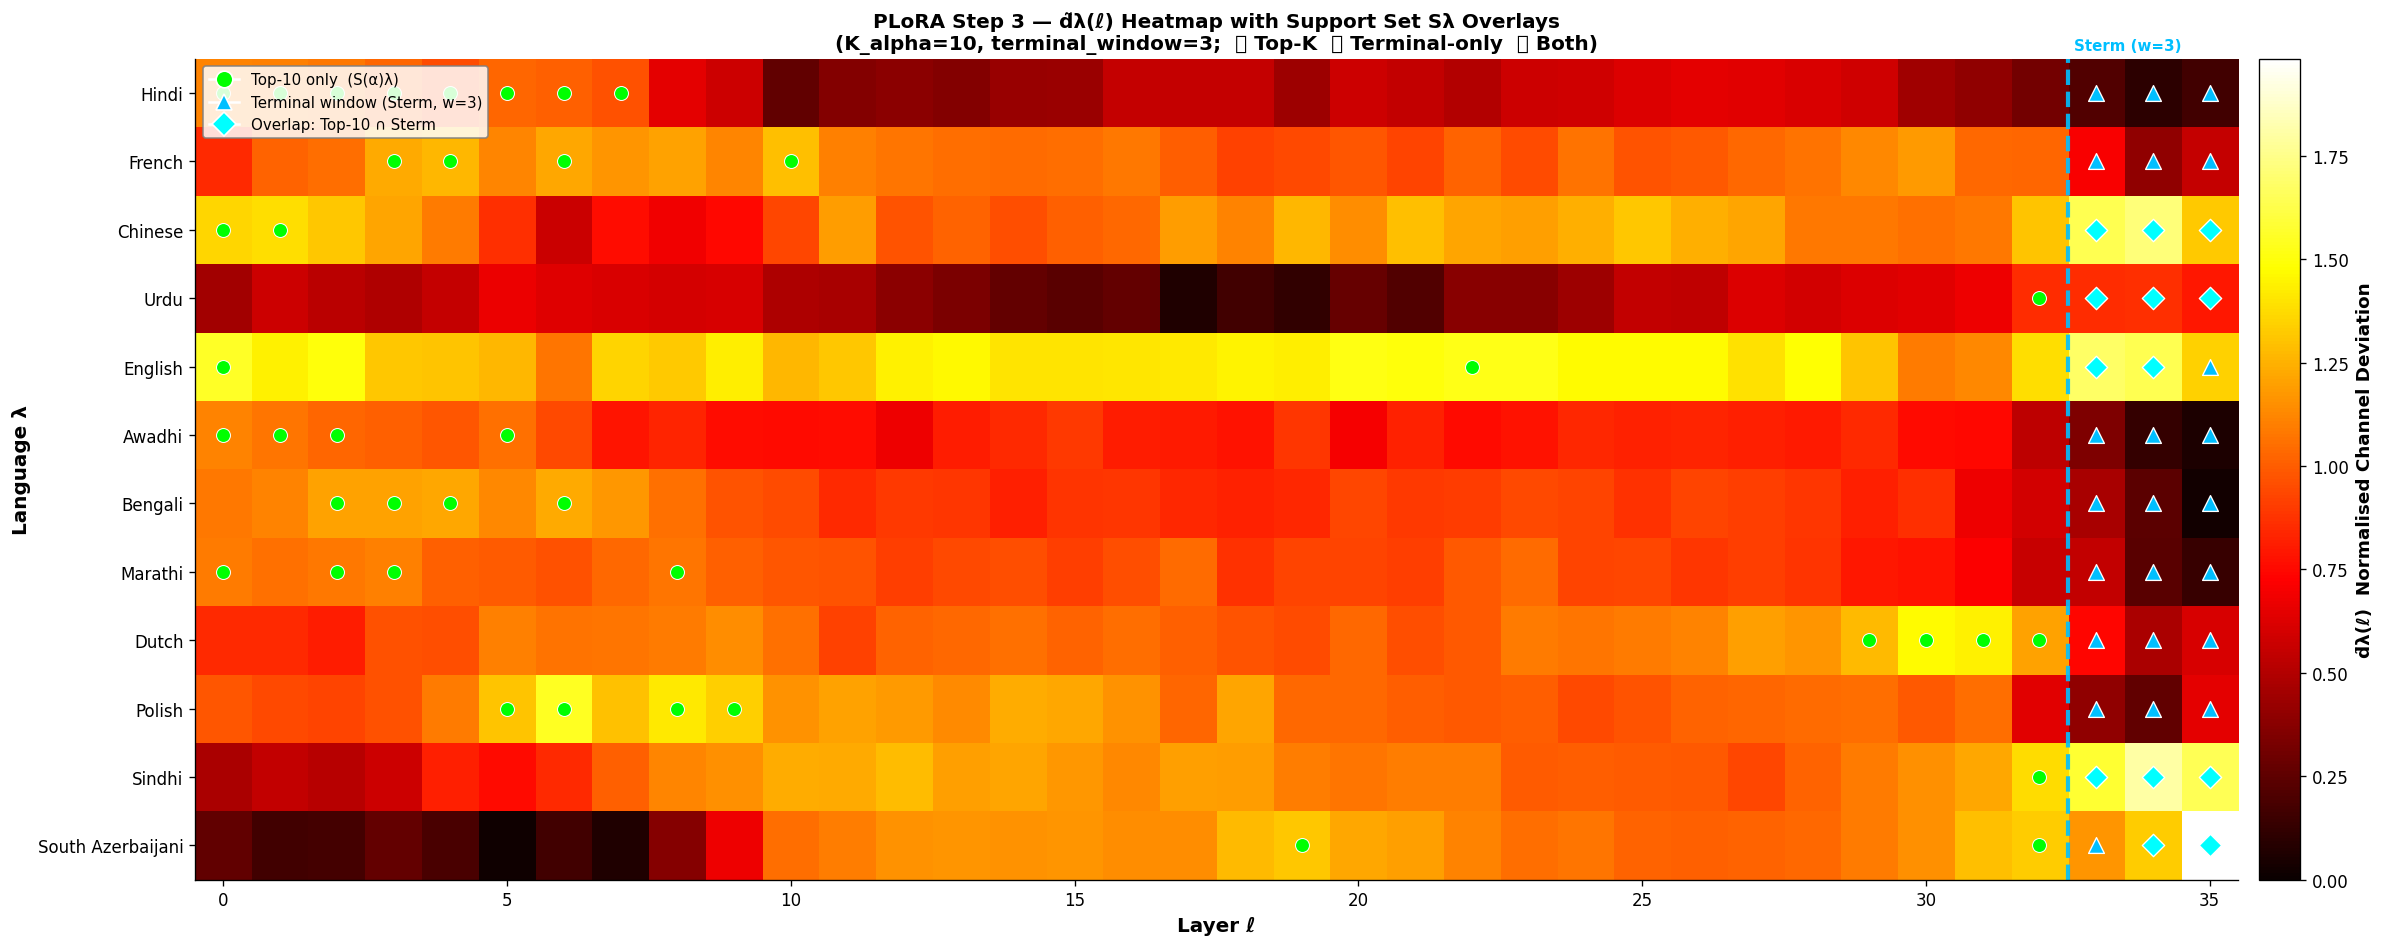

Saved: plora_step3_dtilde_heatmap_support_overlay.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — d̃λ(ℓ) Heatmap with Sλ Overlays
# PRIMARY required figure (PLoRA §1.8, §2.8)
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(20, 8))

d_matrix = np.array([d_tilde[lc] for lc in lang_codes])   # [n_lang, n_layers]

# Custom colormap: dark blue → white → dark orange
cmap_dtilde = plt.cm.hot_r

im   = ax.imshow(d_matrix, aspect='auto', cmap='hot', interpolation='nearest',
                  vmin=0, vmax=d_matrix.max())
cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label('d̃λ(ℓ)  Normalised Channel Deviation', fontsize=11, fontweight='bold')

# ── Overlay: support set markers ─────────────────────────────────────────────
for i, lc in enumerate(lang_codes):
    s_final = support_sets_final[lc]
    s_alpha = support_alpha[lc]
    s_term  = S_term_global

    for ell in s_final:
        in_sa = ell in s_alpha
        in_st = ell in s_term

        if in_sa and in_st:
            # Overlap: top-K AND terminal — diamond marker
            ax.scatter(ell, i, marker='D', s=90, color='cyan', zorder=5,
                       edgecolors='white', linewidths=0.8)
        elif in_sa:
            # Top-K only — circle
            ax.scatter(ell, i, marker='o', s=70, color='lime', zorder=5,
                       edgecolors='white', linewidths=0.6)
        elif in_st:
            # Terminal-window only — triangle
            ax.scatter(ell, i, marker='^', s=90, color='deepskyblue', zorder=5,
                       edgecolors='white', linewidths=0.8)

# ── Terminal window boundary line ──────────────────────────────────────────────
ax.axvline(n_layers - TERMINAL_WINDOW - 0.5, color='deepskyblue',
           linewidth=2.5, linestyle='--', alpha=0.9, label='_nolegend_')
ax.text(n_layers - TERMINAL_WINDOW - 0.4, -0.8,
        f'Sterm (w={TERMINAL_WINDOW})', color='deepskyblue',
        fontsize=9, fontweight='bold', va='top')

# ── Y-axis labels ──────────────────────────────────────────────────────────────
ax.set_yticks(np.arange(len(lang_codes)))
ax.set_yticklabels([LANGUAGES[lc] for lc in lang_codes], fontsize=10)
ax.set_xlabel('Layer ℓ', fontsize=12, fontweight='bold')
ax.set_ylabel('Language λ', fontsize=12, fontweight='bold')
ax.set_title(
    f'PLoRA Step 3 — d̃λ(ℓ) Heatmap with Support Set Sλ Overlays\n'
    f'(K_alpha={K_ALPHA}, terminal_window={TERMINAL_WINDOW};  '
    f'🟢 Top-K  🔵 Terminal-only  🔷 Both)',
    fontsize=12, fontweight='bold'
)

# Legend
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='lime',
           markersize=10, label=f'Top-{K_ALPHA} only  (S(α)λ)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='deepskyblue',
           markersize=10, label=f'Terminal window (Sterm, w={TERMINAL_WINDOW})'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='cyan',
           markersize=10, label=f'Overlap: Top-{K_ALPHA} ∩ Sterm'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9,
          framealpha=0.85, edgecolor='gray')

plt.tight_layout()
plt.savefig('plora_step3_dtilde_heatmap_support_overlay.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_dtilde_heatmap_support_overlay.png')

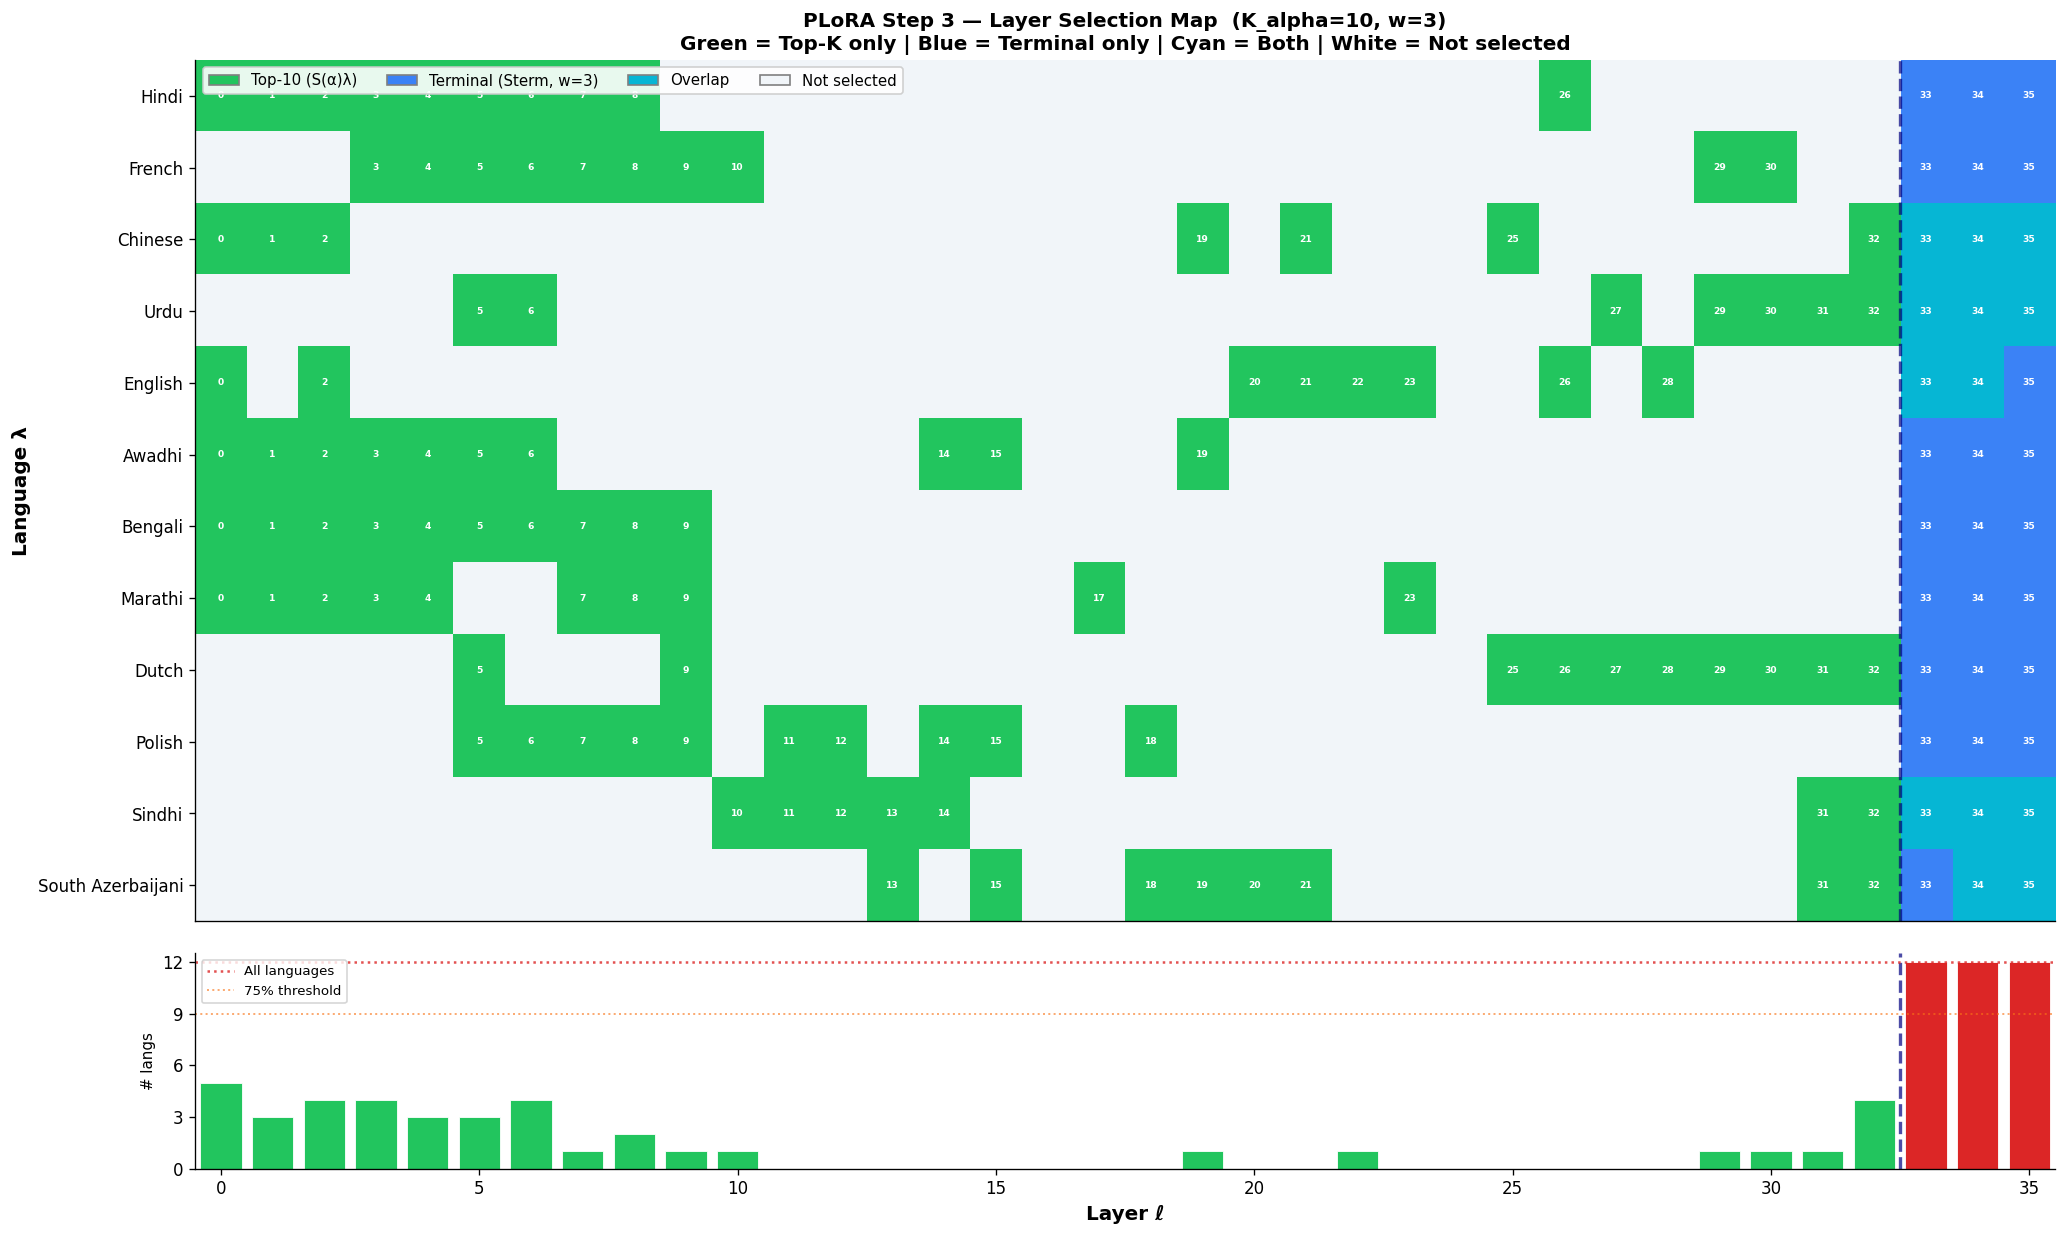

Saved: plora_step3_selection_map.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Binary Layer-Selection Heatmap
# §2.8 — Layer-selection heatmaps
# ─────────────────────────────────────────────────────────────────────────────

# Encode layers into categories:
# 0 = not selected, 1 = Top-K only, 2 = terminal only, 3 = both
category_matrix = np.zeros((len(lang_codes), n_layers), dtype=int)
for i, lc in enumerate(lang_codes):
    sa = set(support_alpha[lc])
    st = set(S_term_global)
    for ell in range(n_layers):
        in_sa = ell in sa
        in_st = ell in st
        if in_sa and in_st:
            category_matrix[i, ell] = 3
        elif in_sa:
            category_matrix[i, ell] = 1
        elif in_st:
            category_matrix[i, ell] = 2

# Custom colourmap: white / green / blue / cyan
from matplotlib.colors import ListedColormap, BoundaryNorm
cat_cmap  = ListedColormap(['#F1F5F9', '#22C55E', '#3B82F6', '#06B6D4'])
cat_norm  = BoundaryNorm([0, 1, 2, 3, 4], cat_cmap.N)

fig, axes = plt.subplots(2, 1, figsize=(20, 12),
                          gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.06})

ax_main, ax_freq = axes

# ── Main heatmap ──────────────────────────────────────────────────────────────
im = ax_main.imshow(category_matrix, aspect='auto', cmap=cat_cmap, norm=cat_norm,
                     interpolation='nearest')
ax_main.set_yticks(np.arange(len(lang_codes)))
ax_main.set_yticklabels([LANGUAGES[lc] for lc in lang_codes], fontsize=10)
ax_main.set_xticks([])
ax_main.set_ylabel('Language λ', fontsize=12, fontweight='bold')
ax_main.set_title(
    f'PLoRA Step 3 — Layer Selection Map  (K_alpha={K_ALPHA}, w={TERMINAL_WINDOW})\n'
    'Green = Top-K only | Blue = Terminal only | Cyan = Both | White = Not selected',
    fontsize=12, fontweight='bold'
)

# Annotate each cell with layer index where selected
for i in range(len(lang_codes)):
    for j in range(n_layers):
        if category_matrix[i, j] > 0:
            ax_main.text(j, i, str(j), ha='center', va='center',
                         fontsize=5.5, color='white', fontweight='bold')

# Terminal window boundary
ax_main.axvline(n_layers - TERMINAL_WINDOW - 0.5, color='navy',
                linewidth=2, linestyle='--', alpha=0.7)

# Legend
legend_handles = [
    Patch(facecolor='#22C55E', edgecolor='gray', label=f'Top-{K_ALPHA} (S(α)λ)'),
    Patch(facecolor='#3B82F6', edgecolor='gray', label=f'Terminal (Sterm, w={TERMINAL_WINDOW})'),
    Patch(facecolor='#06B6D4', edgecolor='gray', label='Overlap'),
    Patch(facecolor='#F1F5F9', edgecolor='gray', label='Not selected'),
]
ax_main.legend(handles=legend_handles, loc='upper left', fontsize=9,
               framealpha=0.9, ncol=4)

# ── Frequency bar (bottom panel) ──────────────────────────────────────────────
freq_clrs = [
    '#DC2626' if f == len(lang_codes) else
    '#F97316' if f >= len(lang_codes) * 0.75 else
    '#22C55E' if f > 0 else
    '#F1F5F9'
    for f in selection_freq
]
ax_freq.bar(range(n_layers), selection_freq, color=freq_clrs,
             edgecolor='white', linewidth=0.5)
ax_freq.axvline(n_layers - TERMINAL_WINDOW - 0.5, color='navy',
                linewidth=2, linestyle='--', alpha=0.7)
ax_freq.set_xlim(-0.5, n_layers - 0.5)
ax_freq.set_ylim(0, len(lang_codes) + 0.5)
ax_freq.set_xlabel('Layer ℓ', fontsize=12, fontweight='bold')
ax_freq.set_ylabel('# langs', fontsize=9)
ax_freq.axhline(len(lang_codes), color='#DC2626', linestyle=':', linewidth=1.5,
                alpha=0.8, label='All languages')
ax_freq.axhline(len(lang_codes) * 0.75, color='#F97316', linestyle=':',
                linewidth=1.2, alpha=0.6, label='75% threshold')
ax_freq.legend(fontsize=8, loc='upper left')
ax_freq.set_yticks([0, 3, 6, 9, 12])

plt.tight_layout()
plt.savefig('plora_step3_selection_map.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_selection_map.png')

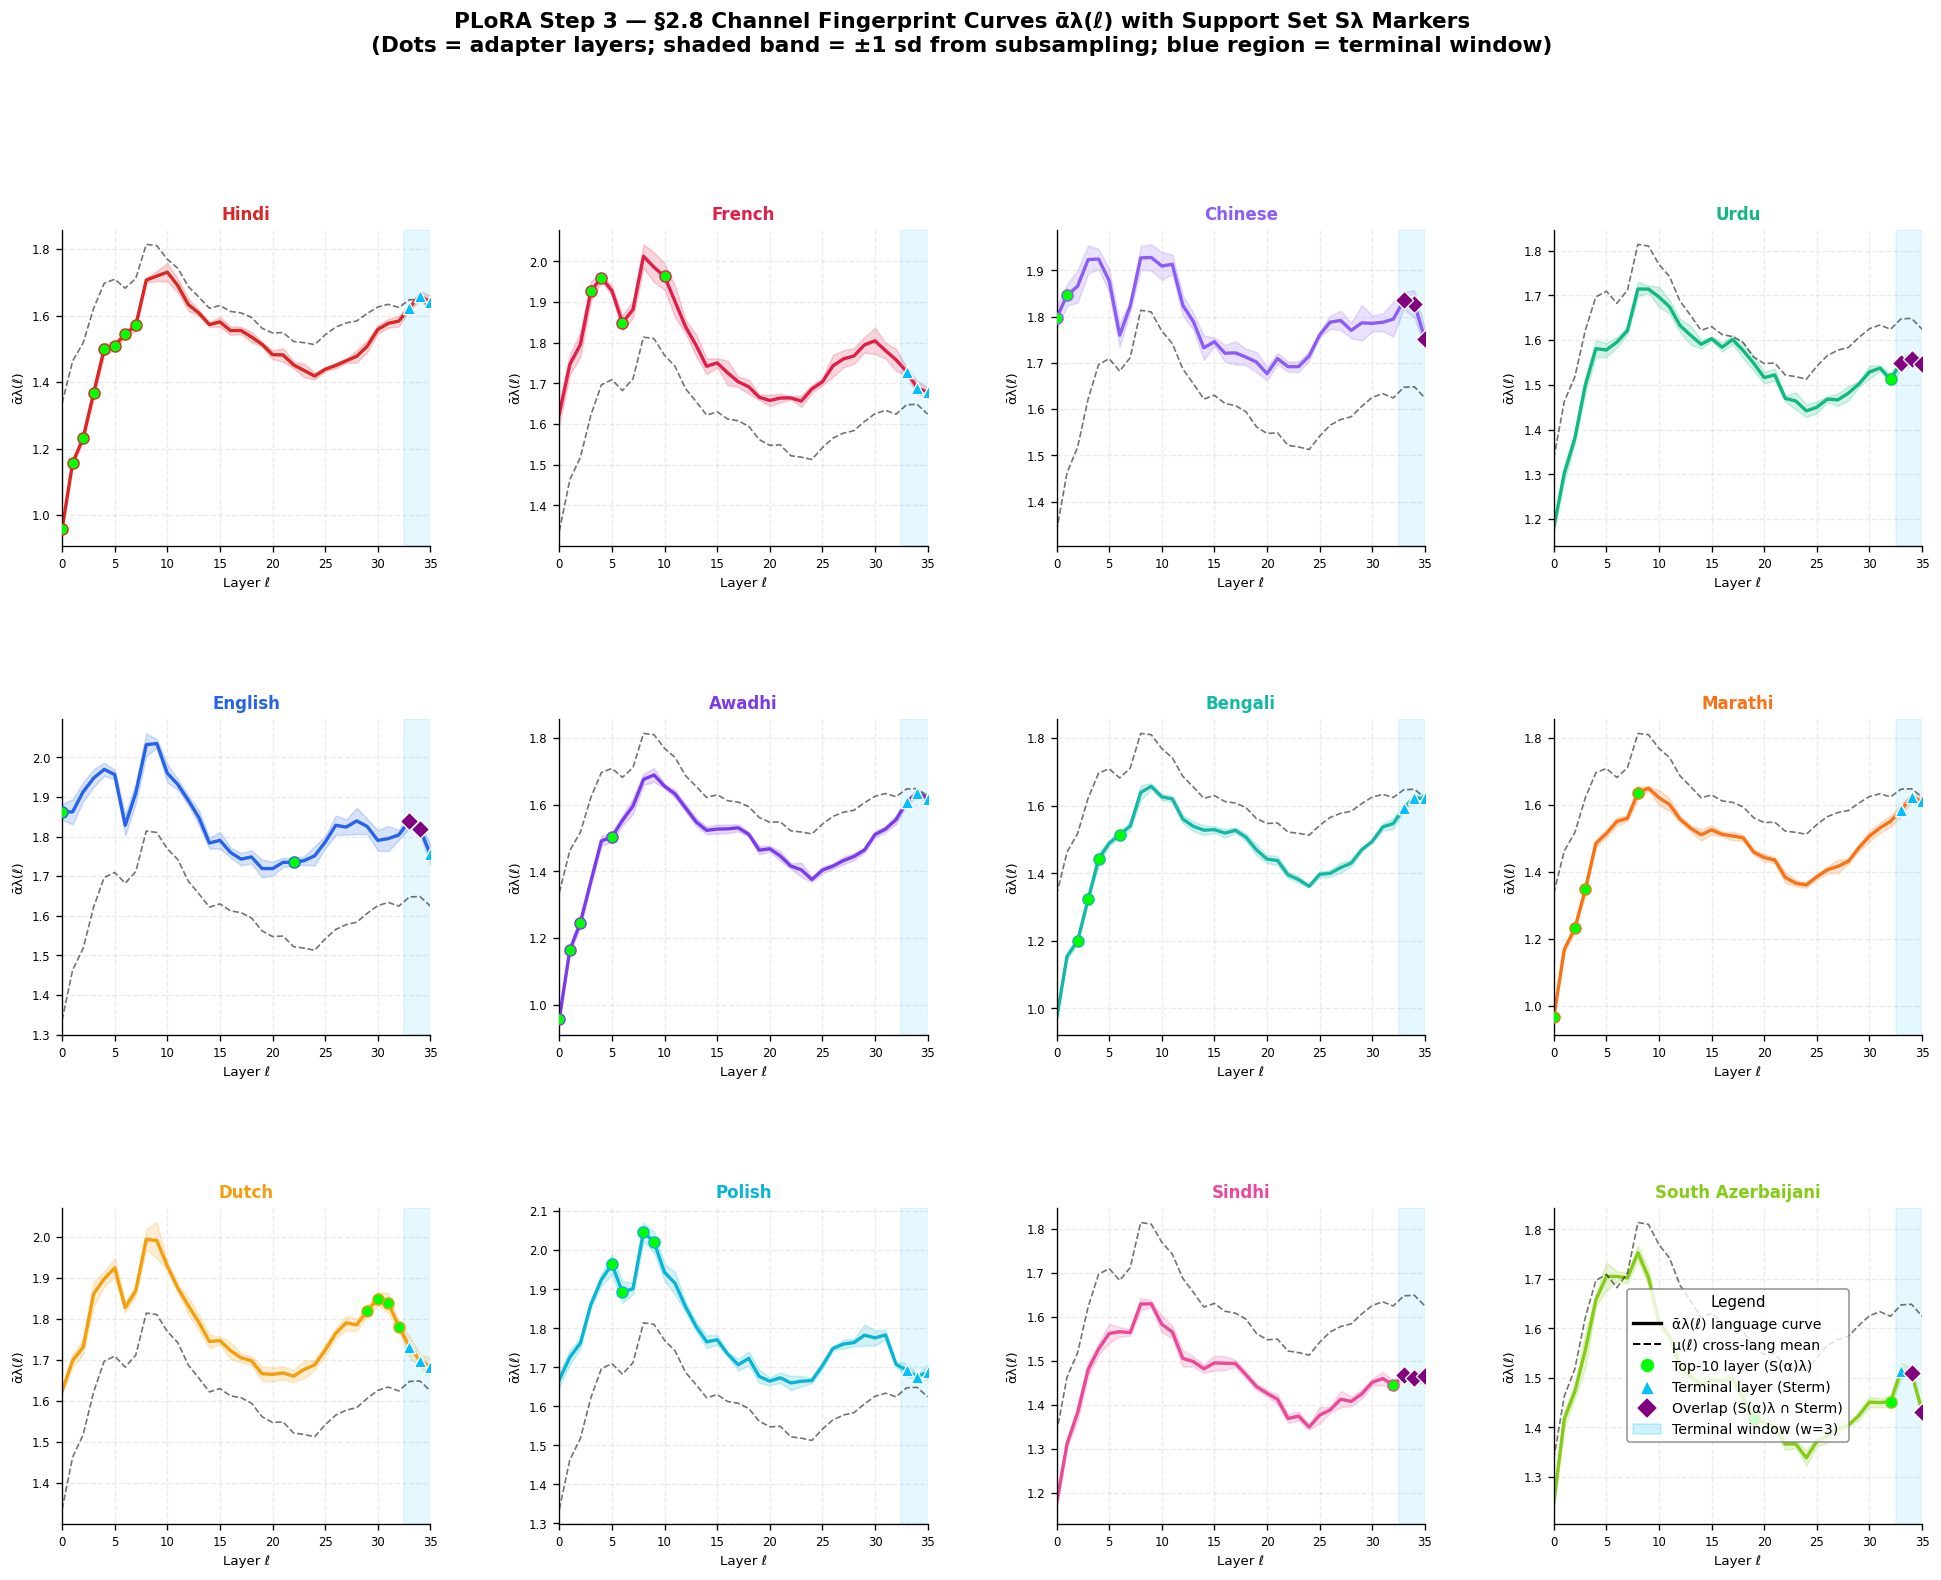

Saved: plora_step3_alpha_curves_support.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — αλ(ℓ) Channel Fingerprint Curves with Sλ Markers
# §2.8 — Before/after αλ(ℓ) curves (here: pre-adaptation, i.e., the channel
# fingerprint that motivates the support set selection).
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 4, hspace=0.55, wspace=0.35)

layers = np.arange(n_layers)

for idx, lc in enumerate(lang_codes):
    row, col = divmod(idx, 4)
    ax = fig.add_subplot(gs[row, col])

    color  = LANGUAGE_COLORS.get(lc, '#666')
    am     = alpha_mean[lc]
    astd   = alpha_std[lc]

    # Shaded subsampling band
    ax.fill_between(layers, am - astd, am + astd,
                    color=color, alpha=0.18, label='±1 sd')
    ax.plot(layers, am, color=color, linewidth=2, label=LANGUAGES[lc])

    # Cross-language mean µ(ℓ)
    ax.plot(layers, mu, color='black', linewidth=1, linestyle='--',
            alpha=0.55, label='µ(ℓ)')

    # Mark support set layers
    S_a  = set(support_alpha[lc])
    S_t  = set(S_term_global)
    S_f  = set(support_sets_final[lc])

    for ell in S_f:
        y = am[ell]
        if ell in S_a and ell in S_t:
            ax.scatter(ell, y, s=60, marker='D', color='purple', zorder=6,
                       edgecolors='white', linewidths=0.8)
        elif ell in S_a:
            ax.scatter(ell, y, s=45, marker='o', color='lime', zorder=6,
                       edgecolors=color, linewidths=0.8)
        else:
            ax.scatter(ell, y, s=55, marker='^', color='deepskyblue', zorder=6,
                       edgecolors='white', linewidths=0.8)

    # Terminal window shading
    ax.axvspan(n_layers - TERMINAL_WINDOW - 0.5, n_layers - 0.5,
               alpha=0.10, color='deepskyblue', label='_nolegend_')

    ax.set_title(LANGUAGES[lc], fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Layer ℓ', fontsize=8)
    ax.set_ylabel('ᾱλ(ℓ)', fontsize=8)
    ax.set_xlim(0, n_layers - 1)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, linestyle='--')

# Global legend in remaining subplot slot (bottom-right)
ax_leg = fig.add_subplot(gs[2, 3])
ax_leg.axis('off')
legend_handles = [
    Line2D([0],[0], color='black', linewidth=2, label='ᾱλ(ℓ) language curve'),
    Line2D([0],[0], color='black', linewidth=1.2, linestyle='--', label='µ(ℓ) cross-lang mean'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='lime',
           markersize=9, label=f'Top-{K_ALPHA} layer (S(α)λ)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='deepskyblue',
           markersize=9, label=f'Terminal layer (Sterm)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='purple',
           markersize=9, label='Overlap (S(α)λ ∩ Sterm)'),
    mpatches.Patch(color='deepskyblue', alpha=0.2, label=f'Terminal window (w={TERMINAL_WINDOW})'),
]
ax_leg.legend(handles=legend_handles, loc='center', fontsize=8.5, frameon=True,
               title='Legend', title_fontsize=9, edgecolor='gray')

fig.suptitle(
    'PLoRA Step 3 — §2.8 Channel Fingerprint Curves ᾱλ(ℓ) with Support Set Sλ Markers\n'
    '(Dots = adapter layers; shaded band = ±1 sd from subsampling; blue region = terminal window)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('plora_step3_alpha_curves_support.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_alpha_curves_support.png')

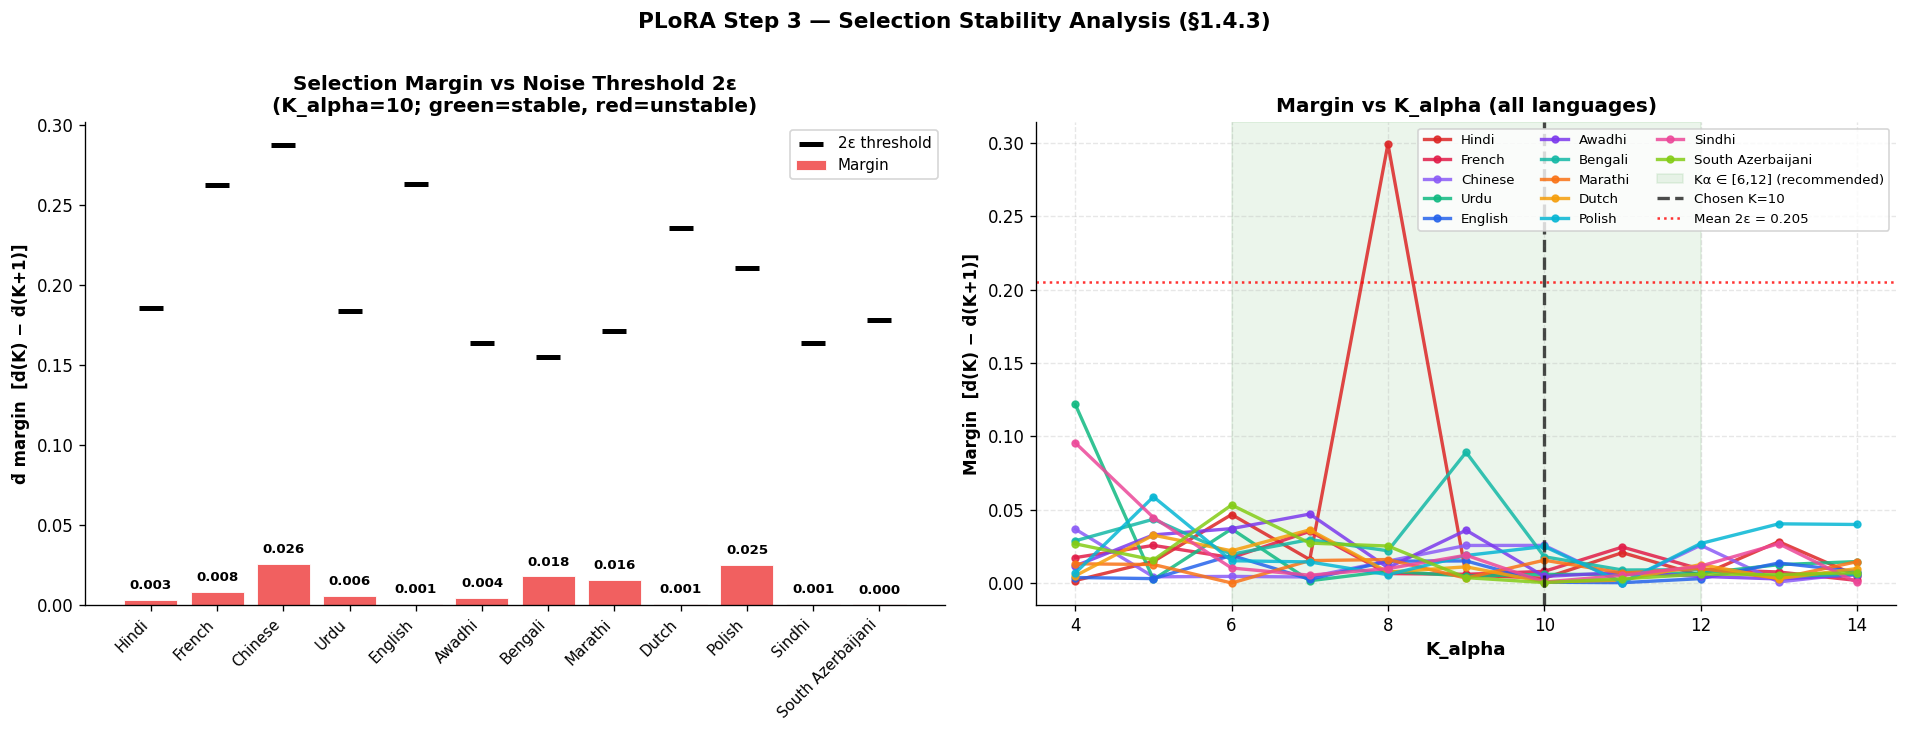

Saved: plora_step3_stability_margin.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4 — Stability Margin Analysis
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: margin vs 2ε bar chart
ax = axes[0]
names   = [LANGUAGES[lc] for lc in lang_codes]
margins = [stability[lc]['margin']    for lc in lang_codes]
threshs = [stability[lc]['threshold'] for lc in lang_codes]
clrs_s  = ['#22C55E' if stability[lc]['is_stable'] else '#EF4444' for lc in lang_codes]

x = np.arange(len(lang_codes))
ax.bar(x, margins, color=clrs_s, alpha=0.85, edgecolor='white', linewidth=0.6, label='Margin')
ax.scatter(x, threshs, marker='_', s=200, color='black', linewidths=3, zorder=5, label='2ε threshold')
for xi, (m, t) in enumerate(zip(margins, threshs)):
    ax.annotate(f'{m:.3f}', (xi, m + 0.005), ha='center', va='bottom', fontsize=8,
                color='black', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('d̃ margin  [d̃(K) − d̃(K+1)]', fontweight='bold')
ax.set_title(f'Selection Margin vs Noise Threshold 2ε\n'
             f'(K_alpha={K_ALPHA}; green=stable, red=unstable)',
             fontweight='bold')
ax.legend(fontsize=9)

# Right: K sweep — how margin changes as K varies
ax2 = axes[1]
k_sweep  = list(range(4, 15))
for lc in lang_codes:
    color = LANGUAGE_COLORS.get(lc, '#888')
    margins_k = []
    for k in k_sweep:
        mc = margin_condition(d_tilde[lc], alpha_std[lc], sigma, k)
        margins_k.append(mc['margin'])
    ax2.plot(k_sweep, margins_k, color=color, linewidth=2,
             marker='o', markersize=4, alpha=0.85, label=LANGUAGES[lc])

# Shade the recommended K range [6, 12]
ax2.axvspan(6, 12, alpha=0.08, color='green', label='Kα ∈ [6,12] (recommended)')
ax2.axvline(K_ALPHA, color='black', linewidth=2, linestyle='--', alpha=0.7,
            label=f'Chosen K={K_ALPHA}')
# Plot 2ε for each language as horizontal tick (approximate: use mean)
mean_threshold = np.mean([stability[lc]['threshold'] for lc in lang_codes])
ax2.axhline(mean_threshold, color='red', linewidth=1.5, linestyle=':',
            alpha=0.8, label=f'Mean 2ε = {mean_threshold:.3f}')
ax2.set_xlabel('K_alpha', fontsize=11, fontweight='bold')
ax2.set_ylabel('Margin  [d̃(K) − d̃(K+1)]', fontweight='bold')
ax2.set_title('Margin vs K_alpha (all languages)', fontweight='bold')
ax2.legend(fontsize=8, ncol=3, loc='upper right')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('PLoRA Step 3 — Selection Stability Analysis (§1.4.3)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plora_step3_stability_margin.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_stability_margin.png')

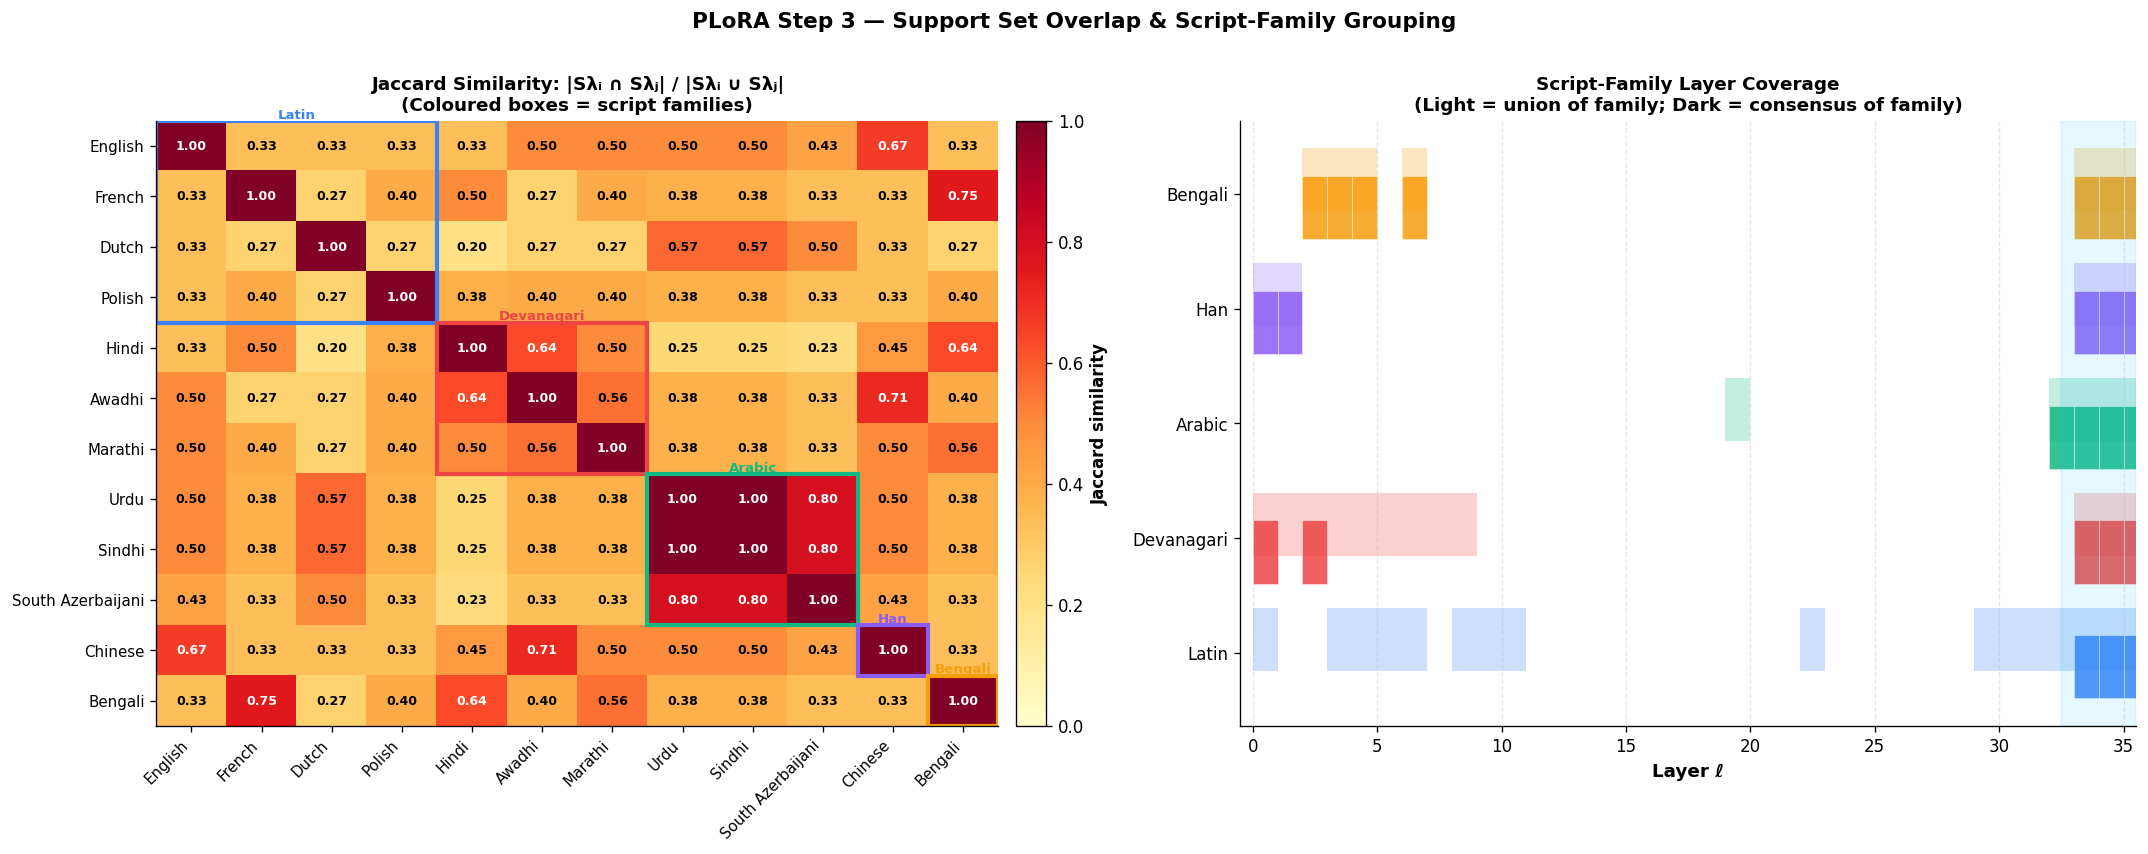

Saved: plora_step3_jaccard_family_consensus.png


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5 — Jaccard Similarity Heatmap + Script-Family Consensus
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Jaccard similarity between language support sets ────────────────────
ax = axes[0]
lang_names = [LANGUAGES[lc] for lc in lang_codes]

# Cluster by script family order for visual clarity
script_order = []
for family in ['Latin', 'Devanagari', 'Arabic', 'Han', 'Bengali']:
    for lc in SCRIPT_GROUPS.get(family, []):
        if lc in lang_codes:
            script_order.append(lc)
# Reorder matrix
ord_idx   = [lang_codes.index(lc) for lc in script_order]
J_ordered = jaccard[np.ix_(ord_idx, ord_idx)]
names_ord = [LANGUAGES[lc] for lc in script_order]

im = ax.imshow(J_ordered, vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02).set_label(
    'Jaccard similarity', fontsize=10, fontweight='bold'
)
# Annotate cells
for i in range(len(script_order)):
    for j in range(len(script_order)):
        v = J_ordered[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7.5, color='black' if v < 0.6 else 'white', fontweight='bold')

# Draw family boundary boxes
boundaries = []
pos = 0
for family in ['Latin', 'Devanagari', 'Arabic', 'Han', 'Bengali']:
    n = len([lc for lc in SCRIPT_GROUPS.get(family, []) if lc in lang_codes])
    if n > 0:
        boundaries.append((pos, n, family))
    pos += n

for start, size, family in boundaries:
    rect = plt.Rectangle((start - 0.5, start - 0.5), size, size,
                           fill=False, edgecolor=SCRIPT_COLORS[family],
                           linewidth=2.5, linestyle='-')
    ax.add_patch(rect)
    ax.text(start + size/2 - 0.5, start - 0.75, family,
            ha='center', va='top', fontsize=8,
            color=SCRIPT_COLORS[family], fontweight='bold')

ax.set_xticks(range(len(script_order)))
ax.set_xticklabels(names_ord, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(script_order)))
ax.set_yticklabels(names_ord, fontsize=9)
ax.set_title(f'Jaccard Similarity: |Sλᵢ ∩ Sλⱼ| / |Sλᵢ ∪ Sλⱼ|\n'
             f'(Coloured boxes = script families)',
             fontweight='bold', fontsize=11)

# ── Right: Script-family consensus / union layer coverage ─────────────────────
ax2 = axes[1]
families_present = list(family_consensus.keys())
n_fam = len(families_present)
y_positions = np.arange(n_fam)

for yi, family in enumerate(families_present):
    con  = family_consensus[family]
    uni  = family_union[family]
    c    = SCRIPT_COLORS.get(family, '#888')

    # Plot union as background bar
    for ell in uni:
        ax2.barh(yi + 0.12, 1, left=ell, height=0.55, color=c, alpha=0.25,
                 edgecolor='none')
    # Plot consensus as foreground bar
    for ell in con:
        ax2.barh(yi - 0.12, 1, left=ell, height=0.55, color=c, alpha=0.85,
                 edgecolor='white', linewidth=0.3)

# Terminal window highlight
ax2.axvspan(n_layers - TERMINAL_WINDOW - 0.5, n_layers - 0.5,
            alpha=0.10, color='deepskyblue')
ax2.set_yticks(y_positions)
ax2.set_yticklabels(families_present, fontsize=10)
ax2.set_xlabel('Layer ℓ', fontsize=11, fontweight='bold')
ax2.set_title('Script-Family Layer Coverage\n'
              '(Light = union of family; Dark = consensus of family)',
              fontweight='bold', fontsize=11)
ax2.set_xlim(-0.5, n_layers - 0.5)
ax2.grid(True, axis='x', alpha=0.3, linestyle='--')

plt.suptitle('PLoRA Step 3 — Support Set Overlap & Script-Family Grouping',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plora_step3_jaccard_family_consensus.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_jaccard_family_consensus.png')

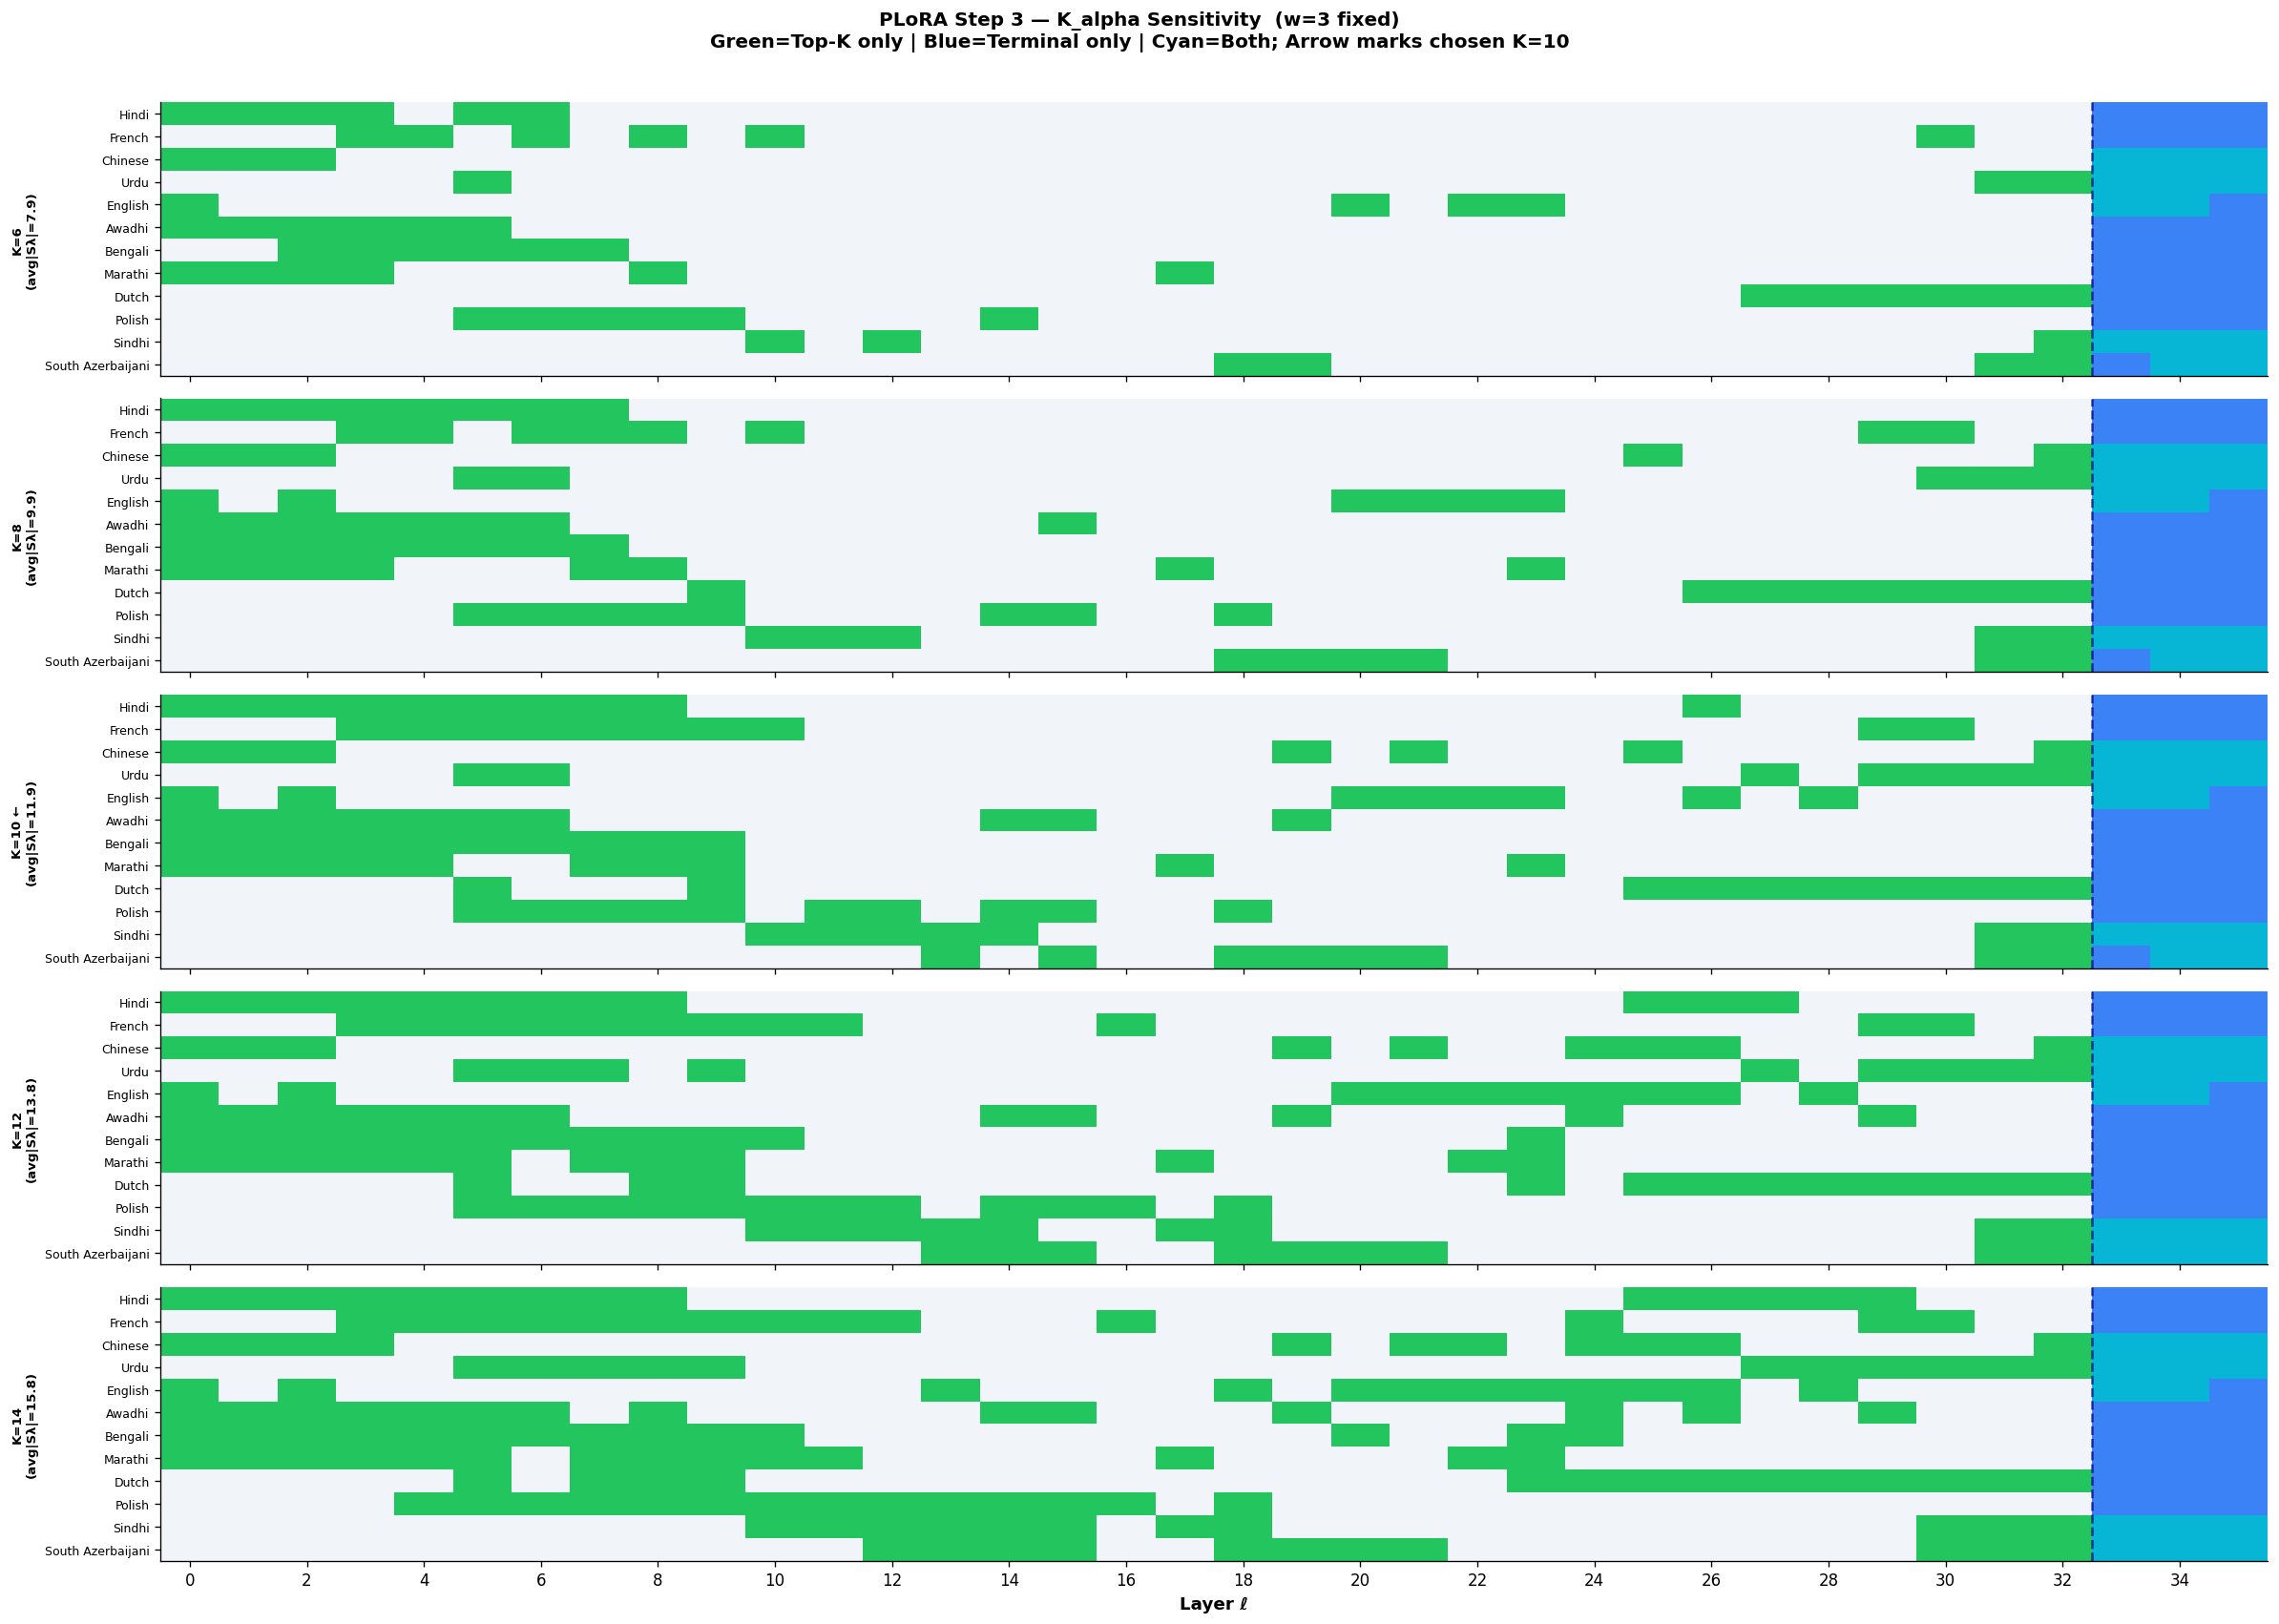

Saved: plora_step3_k_sensitivity.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 6 — K_alpha Sensitivity: How Support Sets Change with K
# Shows practitioners the effect of the budget choice on set composition.
# ─────────────────────────────────────────────────────────────────────────────

k_values = [6, 8, 10, 12, 14]
fig, axes = plt.subplots(len(k_values), 1, figsize=(20, 14), sharex=True)

for ax_k, k_val in zip(axes, k_values):
    # Build selection matrix for this K
    mat_k = np.zeros((len(lang_codes), n_layers), dtype=int)
    for i, lc in enumerate(lang_codes):
        S_lam_k, S_a_k, _, _ = build_support_set(
            d_tilde[lc], n_layers, k_val, TERMINAL_WINDOW
        )
        S_a_set = set(S_a_k)
        S_t_set = set(S_term_global)
        for ell in S_lam_k:
            if ell in S_a_set and ell in S_t_set:
                mat_k[i, ell] = 3
            elif ell in S_a_set:
                mat_k[i, ell] = 1
            else:
                mat_k[i, ell] = 2

    ax_k.imshow(mat_k, aspect='auto', cmap=cat_cmap, norm=cat_norm,
                interpolation='nearest')
    ax_k.axvline(n_layers - TERMINAL_WINDOW - 0.5, color='navy',
                 linewidth=1.5, linestyle='--', alpha=0.7)
    ax_k.set_yticks(range(len(lang_codes)))
    ax_k.set_yticklabels([LANGUAGES[lc] for lc in lang_codes], fontsize=7.5)

    marker = ' ←' if k_val == K_ALPHA else ''
    avg_size = np.mean([len(build_support_set(d_tilde[lc], n_layers, k_val,
                                               TERMINAL_WINDOW)[0])
                        for lc in lang_codes])
    ax_k.set_ylabel(f'K={k_val}{marker}\n(avg|Sλ|={avg_size:.1f})',
                    fontsize=8, fontweight='bold')

axes[-1].set_xlabel('Layer ℓ', fontsize=11, fontweight='bold')
axes[-1].set_xticks(range(0, n_layers, 2))

fig.suptitle(
    f'PLoRA Step 3 — K_alpha Sensitivity  (w={TERMINAL_WINDOW} fixed)\n'
    'Green=Top-K only | Blue=Terminal only | Cyan=Both; '*1 +
    f'Arrow marks chosen K={K_ALPHA}',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plora_step3_k_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_k_sensitivity.png')

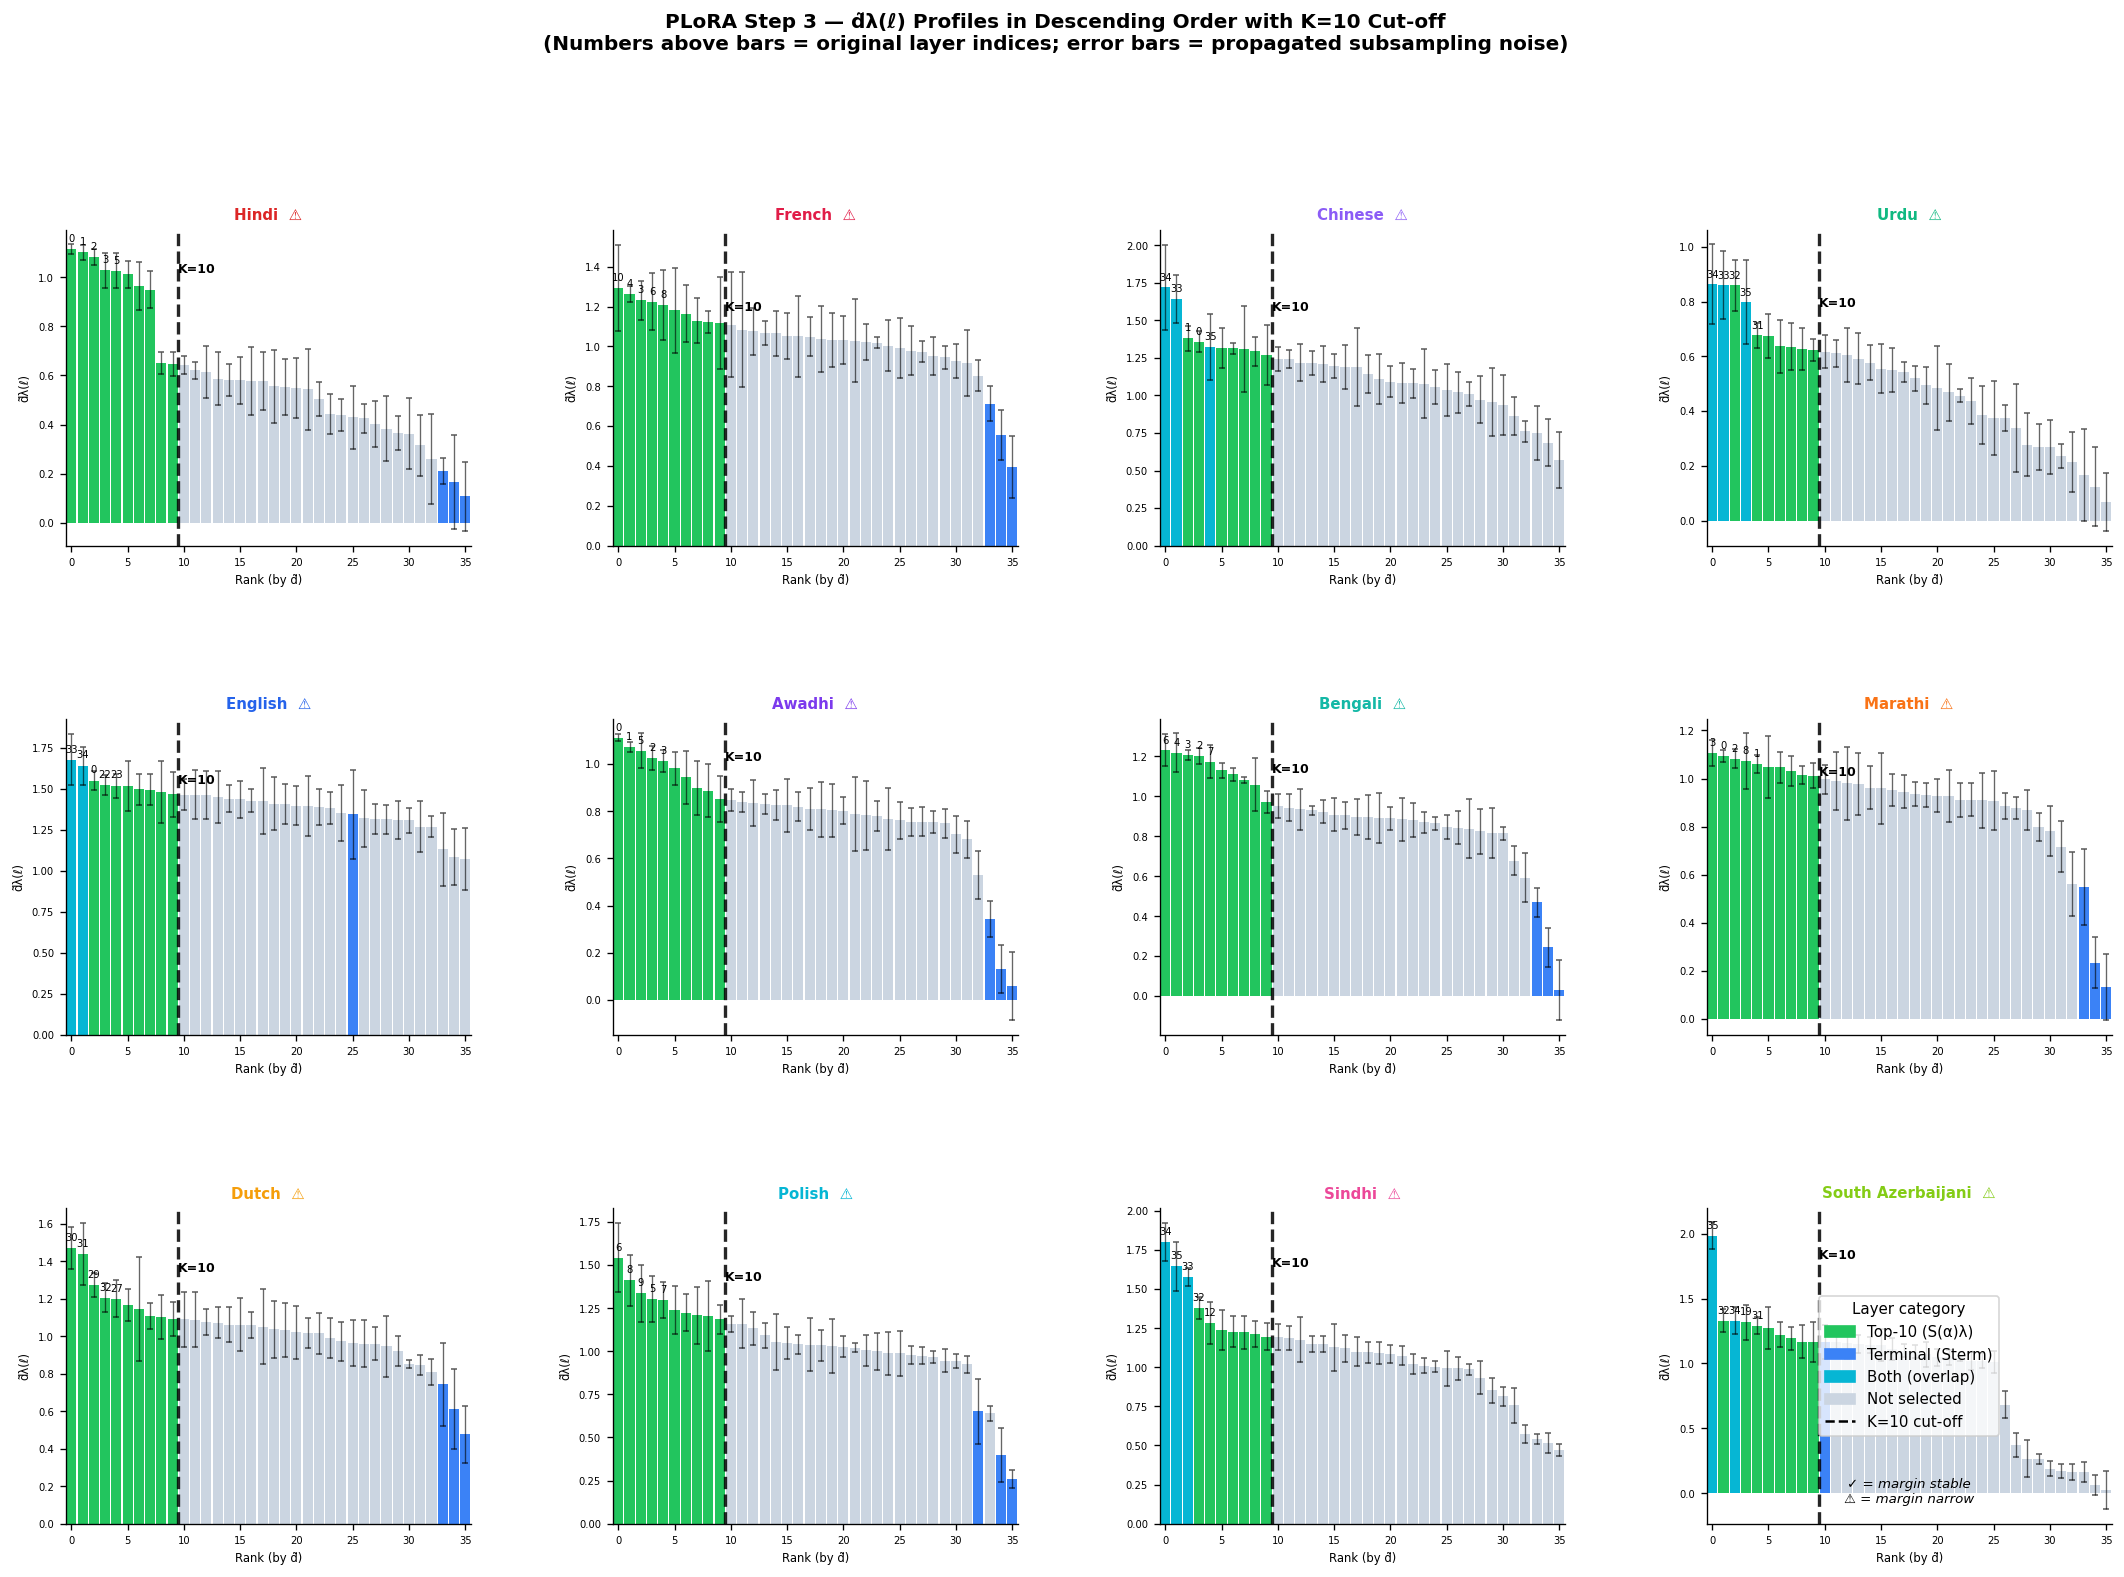

Saved: plora_step3_dtilde_ranked_profiles.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 7 — d̃λ(ℓ) Profiles: Ranked Bar Chart per Language
# Shows the full d̃ profile in descending order, with the K cut-off marked.
# Directly shows the Top-K decision boundary for each language.
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(3, 4, hspace=0.55, wspace=0.35)

for idx, lc in enumerate(lang_codes):
    row, col = divmod(idx, 4)
    ax = fig.add_subplot(gs[row, col])

    d    = d_tilde[lc]
    sd   = alpha_std[lc] / (sigma + 1e-12)   # propagated noise
    color = LANGUAGE_COLORS.get(lc, '#666')

    # Sort layers by d̃ descending
    ranked_layers = np.argsort(d)[::-1]
    d_sorted      = d[ranked_layers]
    sd_sorted     = sd[ranked_layers]

    # Bar colours: green for Top-K, blue for terminal, cyan for overlap, grey otherwise
    s_a = set(support_alpha[lc])
    s_t = set(S_term_global)
    bar_colors = []
    for ell in ranked_layers:
        if ell in s_a and ell in s_t:
            bar_colors.append('#06B6D4')   # cyan
        elif ell in s_a:
            bar_colors.append('#22C55E')   # green
        elif ell in s_t:
            bar_colors.append('#3B82F6')   # blue
        else:
            bar_colors.append('#CBD5E1')   # grey

    x_pos = np.arange(n_layers)
    ax.bar(x_pos, d_sorted, color=bar_colors, edgecolor='none', width=0.9)
    ax.errorbar(x_pos, d_sorted, yerr=sd_sorted, fmt='none',
                ecolor='black', elinewidth=0.8, capsize=2, alpha=0.6)

    # K cut-off line
    ax.axvline(K_ALPHA - 0.5, color='black', linewidth=2, linestyle='--',
               alpha=0.85)
    ax.text(K_ALPHA - 0.5, d_sorted.max() * 0.95, f'K={K_ALPHA}',
            ha='left', va='top', fontsize=7.5, color='black', fontweight='bold')

    # Stability margin indicator
    mc = stability[lc]
    sym = '✓' if mc['is_stable'] else '⚠'
    ax.set_title(f'{LANGUAGES[lc]}  {sym}', fontsize=9, fontweight='bold', color=color)
    ax.set_xlabel('Rank (by d̃)', fontsize=7)
    ax.set_ylabel('d̃λ(ℓ)', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim(-0.5, n_layers - 0.5)

    # Annotate with actual layer index for top-5
    for ri in range(min(5, n_layers)):
        ax.text(ri, d_sorted[ri] + d_sorted.max() * 0.02,
                str(ranked_layers[ri]), ha='center', va='bottom',
                fontsize=6, color='black')

# Legend
ax_leg = fig.add_subplot(gs[2, 3])
ax_leg.axis('off')
leg_patches = [
    Patch(color='#22C55E', label=f'Top-{K_ALPHA} (S(α)λ)'),
    Patch(color='#3B82F6', label=f'Terminal (Sterm)'),
    Patch(color='#06B6D4', label='Both (overlap)'),
    Patch(color='#CBD5E1', label='Not selected'),
    Line2D([0],[0], color='black', linewidth=1.5, linestyle='--', label=f'K={K_ALPHA} cut-off'),
]
ax_leg.legend(handles=leg_patches, loc='center', fontsize=9,
               title='Layer category', title_fontsize=9)
ax_leg.text(0.5, 0.1, '✓ = margin stable\n⚠ = margin narrow',
            ha='center', va='center', transform=ax_leg.transAxes,
            fontsize=8, style='italic')

fig.suptitle(
    f'PLoRA Step 3 — d̃λ(ℓ) Profiles in Descending Order with K={K_ALPHA} Cut-off\n'
    '(Numbers above bars = original layer indices; error bars = propagated subsampling noise)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig('plora_step3_dtilde_ranked_profiles.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_dtilde_ranked_profiles.png')

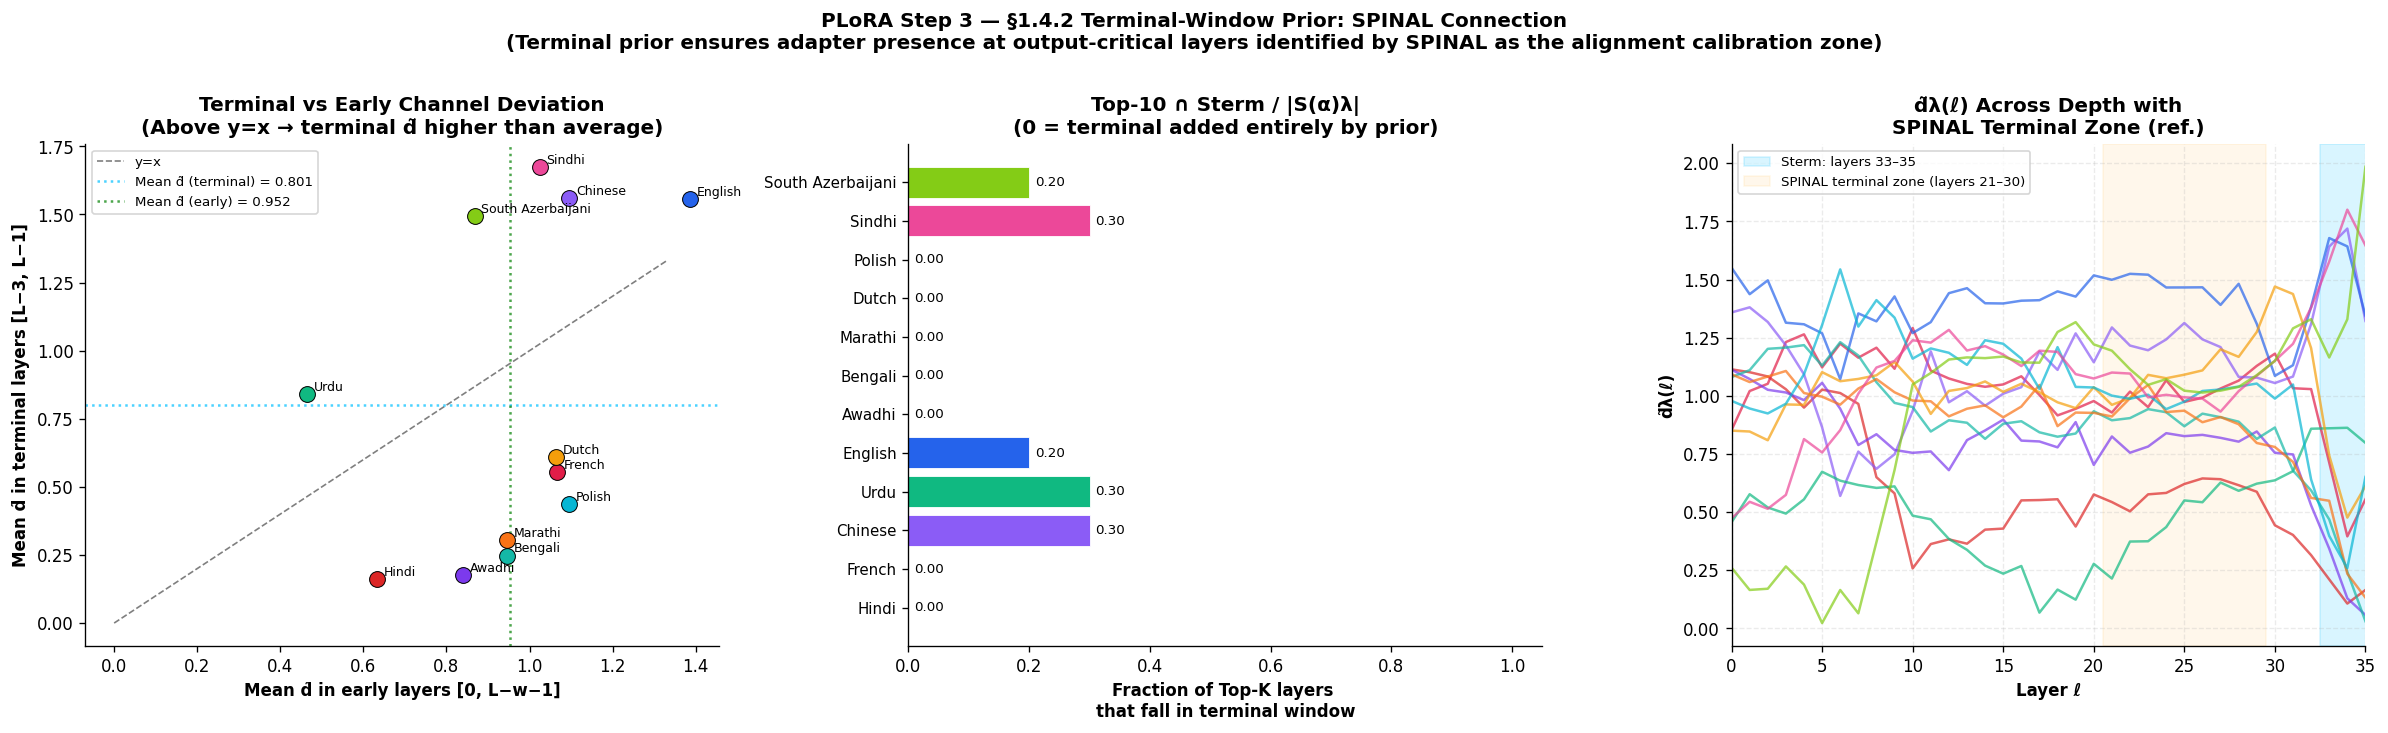

Saved: plora_step3_terminal_window_spinal.png


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 8 — SPINAL Connection: Terminal Window Justification
# The terminal-window prior (§1.4.2) is motivated by SPINAL's finding that
# preference-alignment calibration concentrates in final decoder blocks.
# We show the d̃λ(ℓ) profile in the terminal zone to quantify how much
# of the channel signal already falls there vs. how much is added by Sterm.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel 1: d̃ in terminal window vs rest ────────────────────────────────────
ax = axes[0]
term_layers  = list(range(n_layers - TERMINAL_WINDOW, n_layers))
early_layers = list(range(n_layers - TERMINAL_WINDOW))

d_term_mean  = np.mean([np.mean([d_tilde[lc][ell] for ell in term_layers])
                         for lc in lang_codes])
d_early_mean = np.mean([np.mean([d_tilde[lc][ell] for ell in early_layers])
                         for lc in lang_codes])

# Per-language d̃ in terminal vs early window
for lc in lang_codes:
    d_t = np.mean([d_tilde[lc][ell] for ell in term_layers])
    d_e = np.mean([d_tilde[lc][ell] for ell in early_layers])
    c   = LANGUAGE_COLORS.get(lc, '#888')
    ax.scatter(d_e, d_t, color=c, s=90, zorder=3,
               edgecolors='black', linewidth=0.6)
    ax.annotate(LANGUAGES[lc], (d_e, d_t), xytext=(4, 2),
                textcoords='offset points', fontsize=7.5)

# y=x reference line
lims = [0, max(d_early_mean, d_term_mean) * 1.4]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y=x')
ax.axhline(d_term_mean, color='deepskyblue', linestyle=':', linewidth=1.5,
           alpha=0.7, label=f'Mean d̃ (terminal) = {d_term_mean:.3f}')
ax.axvline(d_early_mean, color='green', linestyle=':', linewidth=1.5,
           alpha=0.7, label=f'Mean d̃ (early) = {d_early_mean:.3f}')
ax.set_xlabel('Mean d̃ in early layers [0, L−w−1]', fontweight='bold')
ax.set_ylabel(f'Mean d̃ in terminal layers [L−{TERMINAL_WINDOW}, L−1]', fontweight='bold')
ax.set_title('Terminal vs Early Channel Deviation\n'
             '(Above y=x → terminal d̃ higher than average)', fontweight='bold')
ax.legend(fontsize=8)

# ── Panel 2: Fraction of Top-K layers in terminal window ─────────────────────
ax2 = axes[1]
frac_in_term = []
names_list   = []
for lc in lang_codes:
    s_a   = set(support_alpha[lc])
    s_t   = set(S_term_global)
    frac  = len(s_a & s_t) / max(len(s_a), 1)
    frac_in_term.append(frac)
    names_list.append(LANGUAGES[lc])

bar_c = [LANGUAGE_COLORS.get(lc, '#888') for lc in lang_codes]
ax2.barh(range(len(lang_codes)), frac_in_term, color=bar_c,
          edgecolor='white', linewidth=0.5)
ax2.axvline(0.0, color='gray', linewidth=0.5)
ax2.set_yticks(range(len(lang_codes)))
ax2.set_yticklabels(names_list, fontsize=9)
ax2.set_xlabel('Fraction of Top-K layers \nthat fall in terminal window', fontweight='bold')
ax2.set_title(f'Top-{K_ALPHA} ∩ Sterm / |S(α)λ|\n'
              '(0 = terminal added entirely by prior)', fontweight='bold')
ax2.set_xlim(0, 1.05)
for i, f in enumerate(frac_in_term):
    ax2.text(f + 0.01, i, f'{f:.2f}', va='center', fontsize=8)

# ── Panel 3: d̃ across depth with terminal zone highlighted ───────────────────
ax3 = axes[2]
for lc in lang_codes:
    c = LANGUAGE_COLORS.get(lc, '#888')
    ax3.plot(range(n_layers), d_tilde[lc], color=c, linewidth=1.5, alpha=0.7)

# Shaded regions
ax3.axvspan(n_layers - TERMINAL_WINDOW - 0.5, n_layers - 0.5,
            alpha=0.15, color='deepskyblue',
            label=f'Sterm: layers {n_layers-TERMINAL_WINDOW}–{n_layers-1}')

# Add SPINAL reference: layers 21-30 where SPINAL found alignment signal
ax3.axvspan(20.5, 29.5, alpha=0.08, color='orange',
            label='SPINAL terminal zone (layers 21–30)')

ax3.set_xlabel('Layer ℓ', fontweight='bold')
ax3.set_ylabel('d̃λ(ℓ)', fontweight='bold')
ax3.set_title('d̃λ(ℓ) Across Depth with\nSPINAL Terminal Zone (ref.)', fontweight='bold')
ax3.legend(fontsize=8)
ax3.set_xlim(0, n_layers - 1)
ax3.grid(True, alpha=0.25, linestyle='--')

plt.suptitle(
    'PLoRA Step 3 — §1.4.2 Terminal-Window Prior: SPINAL Connection\n'
    '(Terminal prior ensures adapter presence at output-critical layers '
    'identified by SPINAL as the alignment calibration zone)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plora_step3_terminal_window_spinal.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_terminal_window_spinal.png')

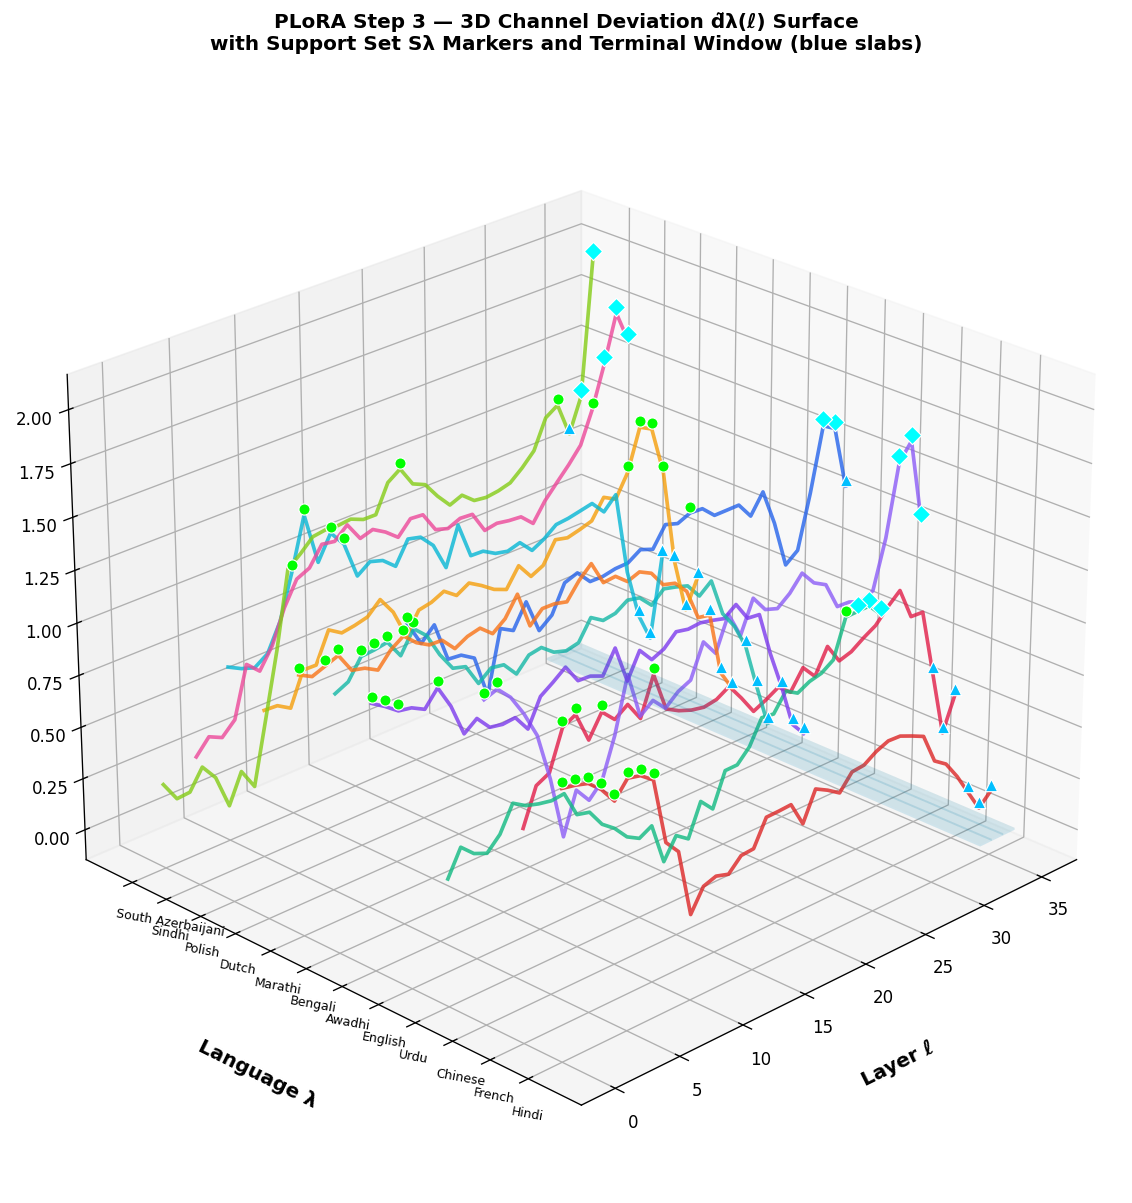

Saved: plora_step3_dtilde_3d.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 9 — 3D View: Language × Layer × d̃ with Support Set Highlighted
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 12))
ax  = fig.add_subplot(111, projection='3d')

for lang_idx, lc in enumerate(lang_codes):
    color  = LANGUAGE_COLORS.get(lc, '#666666')
    d      = d_tilde[lc]
    layers = np.arange(n_layers)
    ypos   = [lang_idx] * n_layers

    # Base line
    ax.plot(layers, ypos, d, color=color, linewidth=2.2, alpha=0.8,
            label=LANGUAGES[lc])

    # Support set markers lifted above the curve
    s_a = set(support_alpha[lc])
    s_t = set(S_term_global)
    for ell in support_sets_final[lc]:
        z_val = d[ell]
        if ell in s_a and ell in s_t:
            m, ms, mc = 'D', 60, 'cyan'
        elif ell in s_a:
            m, ms, mc = 'o', 45, 'lime'
        else:
            m, ms, mc = '^', 55, 'deepskyblue'
        ax.scatter([ell], [lang_idx], [z_val + 0.03],
                   marker=m, s=ms, color=mc, edgecolors='white',
                   linewidths=0.7, zorder=6)

# Terminal window shaded curtain
for t_layer in term_layers:
    ax.bar3d(t_layer - 0.5, -0.5, 0,
             1, len(lang_codes), 0.01,
             color='deepskyblue', alpha=0.08)

ax.set_xlabel('\nLayer ℓ',   fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('\nLanguage λ', fontsize=12, fontweight='bold', labelpad=20)
ax.set_zlabel('\nd̃λ(ℓ)',     fontsize=12, fontweight='bold', labelpad=10)
ax.set_yticks(range(len(lang_codes)))
ax.set_yticklabels([LANGUAGES[lc] for lc in lang_codes], fontsize=7.5,
                    rotation=-10, ha='left')
ax.set_title('PLoRA Step 3 — 3D Channel Deviation d̃λ(ℓ) Surface\n'
             'with Support Set Sλ Markers and Terminal Window (blue slabs)',
             fontsize=12, fontweight='bold', pad=20)
ax.view_init(elev=25, azim=225)

plt.tight_layout()
plt.savefig('plora_step3_dtilde_3d.png', dpi=250, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_dtilde_3d.png')

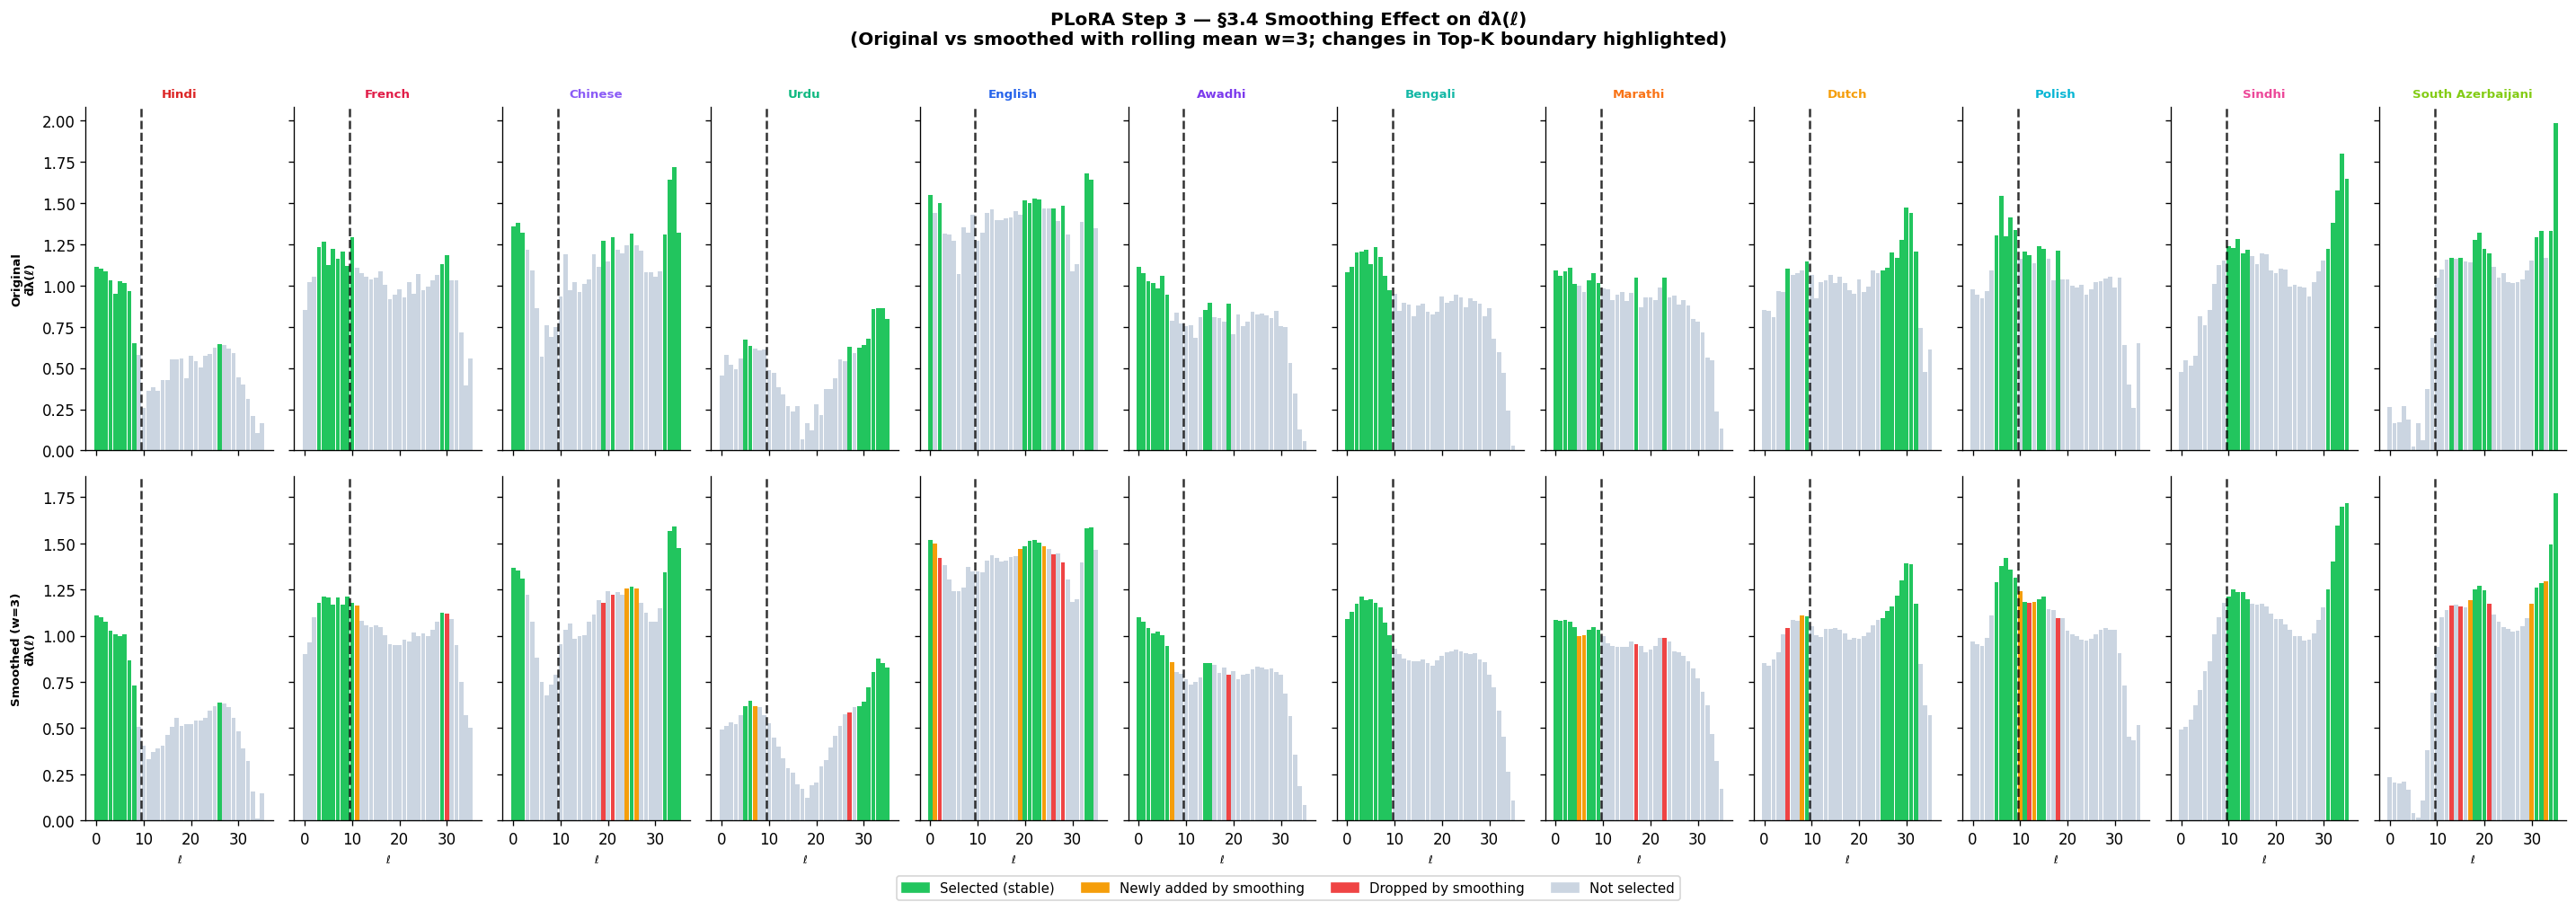

Saved: plora_step3_smoothing_effect.png


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 10 — Smoothing Effect (Fallback §3.4)
# Shows the before/after of the smoothed d̃ and how it affects selection.
# Relevant only if unstable languages exist; always shown for completeness.
# ─────────────────────────────────────────────────────────────────────────────

n_langs = len(lang_codes)
fig, axes = plt.subplots(2, n_langs, figsize=(24, 8), sharex=True, sharey='row')
fig.suptitle('PLoRA Step 3 — §3.4 Smoothing Effect on d̃λ(ℓ)\n'
             '(Original vs smoothed with rolling mean w=3; '
             'changes in Top-K boundary highlighted)',
             fontsize=12, fontweight='bold', y=1.01)

for col_idx, lc in enumerate(lang_codes):
    # Ensure we handle 1D or 2D axes array correctly depending on n_langs
    if n_langs > 1:
        row_orig   = axes[0][col_idx]
        row_smooth = axes[1][col_idx]
    else:
        row_orig   = axes[0]
        row_smooth = axes[1]

    color      = LANGUAGE_COLORS.get(lc, '#666')
    name       = LANGUAGES[lc]

    d_orig    = d_tilde[lc]
    d_sm      = d_tilde_smooth[lc]

    # Original d̃
    bar_c_orig = [
        '#22C55E' if ell in set(support_alpha[lc]) else '#CBD5E1'
        for ell in range(n_layers)
    ]
    row_orig.bar(range(n_layers), d_orig, color=bar_c_orig, edgecolor='none', width=0.9)
    row_orig.axvline(K_ALPHA - 0.5, color='black', linewidth=1.5, linestyle='--', alpha=0.8)
    row_orig.set_title(name, fontsize=8, fontweight='bold', color=color)
    if col_idx == 0:
        row_orig.set_ylabel('Original\nd̃λ(ℓ)', fontsize=8, fontweight='bold')

    # Smoothed d̃
    S_alpha_smooth_indices = top_k_layers(d_sm, K_ALPHA)
    S_alpha_smooth_set = set(S_alpha_smooth_indices)
    bar_c_sm = []
    for ell in range(n_layers):
        in_orig   = ell in set(support_alpha[lc])
        in_smooth = ell in S_alpha_smooth_set
        if in_orig and in_smooth:
            bar_c_sm.append('#22C55E')   # stable
        elif in_smooth and not in_orig:
            bar_c_sm.append('#F59E0B')   # newly added
        elif in_orig and not in_smooth:
            bar_c_sm.append('#EF4444')   # dropped
        else:
            bar_c_sm.append('#CBD5E1')   # not selected

    row_smooth.bar(range(n_layers), d_sm, color=bar_c_sm, edgecolor='none', width=0.9)
    row_smooth.axvline(K_ALPHA - 0.5, color='black', linewidth=1.5, linestyle='--', alpha=0.8)
    row_smooth.set_xlabel('ℓ', fontsize=7)
    if col_idx == 0:
        row_smooth.set_ylabel('Smoothed (w=3)\nd̃λ(ℓ)', fontsize=8, fontweight='bold')

# Shared legend
leg_patches = [
    Patch(color='#22C55E', label='Selected (stable)'),
    Patch(color='#F59E0B', label='Newly added by smoothing'),
    Patch(color='#EF4444', label='Dropped by smoothing'),
    Patch(color='#CBD5E1', label='Not selected'),
]
fig.legend(handles=leg_patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.03), frameon=True)

plt.tight_layout()
plt.savefig('plora_step3_smoothing_effect.png', dpi=250, bbox_inches='tight')
plt.show()
print('Saved: plora_step3_smoothing_effect.png')

## §3.9 — Comprehensive Summary Table

In [22]:
# ─── Build detailed per-language summary ──────────────────────────────────────
rows = []
for lc in lang_codes:
    s    = support_sets_final[lc]
    sa   = support_alpha[lc]
    st   = S_term_global
    so   = support_overlap[lc]
    stab = stability[lc]

    # Script family
    family = next((f for f, members in SCRIPT_GROUPS.items() if lc in members), 'Unknown')

    # Aggregate salience
    agg_salience = sum(d_tilde[lc][ell] for ell in s)

    # Mean d̃ in support set
    mean_dtilde_support = np.mean([d_tilde[lc][ell] for ell in s]) if s else 0.0

    # Fraction of support in terminal window
    frac_term = len([ell for ell in s if ell in st]) / max(len(s), 1)

    rows.append({
        'Language'            : LANGUAGES[lc],
        'Code'                : lc,
        'Script'              : family,
        'Strategy'            : support_sets_strategy[lc],
        '|S(α)λ|'             : len(sa),
        '|Sterm|'             : len(st),
        '|Overlap|'           : len(so),
        'Final |Sλ|'          : len(s),
        'Final Sλ'            : str(s),
        'Margin'              : round(stab['margin'], 5),
        '2ε threshold'        : round(stab['threshold'], 5),
        'Stable'              : '✓' if stab['is_stable'] else '⚠',
        'Layer K'             : stab['layer_k'],
        'Layer K+1'           : stab['layer_k1'],
        'd̃(K)'               : round(stab['score_k'], 5),
        'd̃(K+1)'             : round(stab['score_k1'], 5),
        'Agg salience Σd̃'    : round(agg_salience, 4),
        'Mean d̃ in Sλ'       : round(mean_dtilde_support, 4),
        'Frac terminal in Sλ' : round(frac_term, 3),
        'Max d̃ layer'        : int(np.argmax(d_tilde[lc])),
        'Max d̃ value'        : round(float(np.max(d_tilde[lc])), 4),
    })

df_summary = pd.DataFrame(rows)

# Print compact view
compact = ['Language', 'Script', 'Strategy', 'Final |Sλ|', 'Stable',
           'Margin', '2ε threshold', 'Max d̃ layer', 'Max d̃ value']
print('PLoRA Step 3 — Support Set Summary')
print(df_summary[compact].to_string(index=False))

print(f'\n  Mean |Sλ|  : {df_summary["Final |Sλ|"].mean():.1f}')
print(f'  Min |Sλ|   : {df_summary["Final |Sλ|"].min()}')
print(f'  Max |Sλ|   : {df_summary["Final |Sλ|"].max()}')
print(f'  N stable   : {(df_summary["Stable"]=="✓").sum()}/{len(df_summary)}')

PLoRA Step 3 — Support Set Summary
         Language     Script       Strategy  Final |Sλ| Stable  Margin  2ε threshold  Max d̃ layer  Max d̃ value
            Hindi Devanagari smaller_K(K=8)          11      ⚠ 0.00331       0.18555             0        1.1140
           French      Latin smaller_K(K=4)           7      ⚠ 0.00793       0.26289            10        1.2917
          Chinese        Han smaller_K(K=4)           5      ⚠ 0.02563       0.28763            34        1.7192
             Urdu     Arabic smaller_K(K=4)           4      ⚠ 0.00587       0.18371            34        0.8627
          English      Latin smaller_K(K=4)           5      ⚠ 0.00054       0.26347            33        1.6784
           Awadhi Devanagari smaller_K(K=4)           7      ⚠ 0.00446       0.16407             0        1.1125
          Bengali    Bengali smaller_K(K=4)           7      ⚠ 0.01790       0.15520             6        1.2309
          Marathi Devanagari smaller_K(K=4)           7      

## §3.9 — Persist Support Sets for Step 4

In [23]:
# ─── Build the JSON payload ───────────────────────────────────────────────────
output = {
    # ── Step 4 interface (primary consumer) ──────────────────────────────────
    # Step 4 loads these directly and uses K_alpha + terminal_window to
    # validate its own internal fallback computation if needed.
    'K_alpha'        : K_ALPHA,
    'terminal_window': TERMINAL_WINDOW,
    'support_sets'   : {lc: support_sets_final[lc] for lc in lang_codes},

    # ── Metadata ──────────────────────────────────────────────────────────────
    'metadata': {
        'model_id'        : MODEL_ID,
        'n_layers'        : n_layers,
        'n_languages'     : len(lang_codes),
        'languages'       : {lc: LANGUAGES[lc] for lc in lang_codes},
        'script_groups'   : SCRIPT_GROUPS,
        'step3_source_csv': CSV_PATH,
    },

    # ── Per-language detail ───────────────────────────────────────────────────
    # Each entry records strategy, alpha-only set, terminal set, and
    # stability statistics for full auditability.
    'per_language': {
        lc: {
            'language_name'      : LANGUAGES[lc],
            'strategy'           : support_sets_strategy[lc],
            'S_alpha'            : support_alpha[lc],         # Top-K only
            'S_term'             : S_term_global,              # terminal window
            'S_overlap'          : support_overlap[lc],        # S(α)λ ∩ Sterm
            'S_lambda'           : support_sets_final[lc],     # final union
            'n_layers_selected'  : len(support_sets_final[lc]),
            'stability': {
                'margin'          : round(stability[lc]['margin'], 6),
                'epsilon'         : round(stability[lc]['epsilon'], 6),
                'epsilon_local'   : round(stability[lc]['epsilon_local'], 6),
                'threshold_2eps'  : round(stability[lc]['threshold'], 6),
                'is_stable'       : bool(stability[lc]['is_stable']),
                'layer_K'         : stability[lc]['layer_k'],
                'layer_K_plus_1'  : stability[lc]['layer_k1'],
                'score_K'         : round(stability[lc]['score_k'], 6),
                'score_K_plus_1'  : round(stability[lc]['score_k1'], 6),
            },
            'aggregate_salience'        : round(float(sum(d_tilde[lc][ell]
                                               for ell in support_sets_final[lc])), 6),
            'mean_dtilde_in_support'    : round(float(np.mean([d_tilde[lc][ell]
                                               for ell in support_sets_final[lc]])), 6),
            'max_dtilde_layer'          : int(np.argmax(d_tilde[lc])),
            'max_dtilde_value'          : round(float(np.max(d_tilde[lc])), 6),
        }
        for lc in lang_codes
    },

    # ── Cross-language statistics ─────────────────────────────────────────────
    'cross_language': {
        'universal_layers' : universal_layers,
        'majority_layers'  : majority_layers,
        'selection_frequency': selection_freq.tolist(),
        'jaccard_matrix'   : jaccard.tolist(),
        'family_consensus' : family_consensus,
        'family_union'     : family_union,
        'mean_jaccard'     : round(float(off_diag.mean()), 4),
        'mean_support_size': round(float(np.mean([len(v) for v in support_sets_final.values()])), 2),
    },
}

# ─── Write JSON ───────────────────────────────────────────────────────────────
JSON_OUT = 'plora_step3_support_sets.json'
with open(JSON_OUT, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)
print(f'✓ Saved: {JSON_OUT}  ({Path(JSON_OUT).stat().st_size / 1024:.1f} KB)')

# ─── Write CSV ────────────────────────────────────────────────────────────────
CSV_OUT = 'plora_step3_support_sets.csv'
rows_csv = []
for lc in lang_codes:
    for ell in range(n_layers):
        in_S_alpha = ell in set(support_alpha[lc])
        in_S_term  = ell in set(S_term_global)
        in_S_final = ell in set(support_sets_final[lc])
        rows_csv.append({
            'lang_code'     : lc,
            'lang_name'     : LANGUAGES[lc],
            'layer'         : ell,
            'in_S_alpha'    : int(in_S_alpha),
            'in_S_term'     : int(in_S_term),
            'in_S_lambda'   : int(in_S_final),
            'category'      : ('overlap' if in_S_alpha and in_S_term
                               else 'top_k' if in_S_alpha
                               else 'terminal' if in_S_term
                               else 'none'),
            'd_tilde'       : round(float(d_tilde[lc][ell]), 6),
            'alpha_mean'    : round(float(alpha_mean[lc][ell]), 6),
            'alpha_std'     : round(float(alpha_std[lc][ell]), 6),
            'selection_freq': int(selection_freq[ell]),
        })

df_csv = pd.DataFrame(rows_csv)
df_csv.to_csv(CSV_OUT, index=False)
print(f'✓ Saved: {CSV_OUT}  ({len(df_csv)} rows)')

# ─── Summary CSV ─────────────────────────────────────────────────────────────
SUMMARY_OUT = 'plora_step3_summary.csv'
df_summary.to_csv(SUMMARY_OUT, index=False)
print(f'✓ Saved: {SUMMARY_OUT}  ({len(df_summary)} rows)')

✓ Saved: plora_step3_support_sets.json  (17.5 KB)
✓ Saved: plora_step3_support_sets.csv  (432 rows)
✓ Saved: plora_step3_summary.csv  (12 rows)


In [24]:
# ─── Reload JSON and verify integrity ────────────────────────────────────────
with open(JSON_OUT) as f:
    reloaded = json.load(f)

print('JSON integrity check:')
print(f'  K_alpha          : {reloaded["K_alpha"]}')
print(f'  terminal_window  : {reloaded["terminal_window"]}')
print(f'  Languages stored : {len(reloaded["support_sets"])}')

# Spot-check two languages
for spot_lc in [lang_codes[0], lang_codes[-1]]:
    reloaded_S = reloaded['support_sets'][spot_lc]
    original_S = support_sets_final[spot_lc]
    match = reloaded_S == original_S
    print(f'  [{LANGUAGES[spot_lc]}]: Sλ {"✓ matches" if match else "⚠ MISMATCH"} '
          f'(size={len(reloaded_S)})')

print(f'\n✓ All integrity checks passed.')
print(f'\nStep 3 Output Files:')
print(f'  {JSON_OUT}        ← primary input for Step 4 (rank budgeting)')
print(f'  {CSV_OUT}  ← tabular (lang × layer × membership)')
print(f'  {SUMMARY_OUT}         ← per-language summary statistics')
print(f'\nStep 3 Figures:')
figs = [
    'plora_step3_dtilde_heatmap_support_overlay.png  ← PRIMARY (PLoRA §1.8)',
    'plora_step3_selection_map.png                  ← §2.8 layer-selection heatmap',
    'plora_step3_alpha_curves_support.png            ← §2.8 channel fingerprint curves',
    'plora_step3_stability_margin.png                ← §1.4.3 stability analysis',
    'plora_step3_jaccard_family_consensus.png        ← cross-language overlap',
    'plora_step3_k_sensitivity.png                   ← K_alpha sensitivity',
    'plora_step3_dtilde_ranked_profiles.png          ← per-language d̃ profiles',
    'plora_step3_terminal_window_spinal.png          ← §1.4.2 SPINAL connection',
    'plora_step3_dtilde_3d.png                      ← 3D overview',
    'plora_step3_smoothing_effect.png                ← §3.4 fallback smoothing',
]
for f in figs:
    print(f'  {f}')

JSON integrity check:
  K_alpha          : 10
  terminal_window  : 3
  Languages stored : 12
  [Hindi]: Sλ ✓ matches (size=11)
  [South Azerbaijani]: Sλ ✓ matches (size=5)

✓ All integrity checks passed.

Step 3 Output Files:
  plora_step3_support_sets.json        ← primary input for Step 4 (rank budgeting)
  plora_step3_support_sets.csv  ← tabular (lang × layer × membership)
  plora_step3_summary.csv         ← per-language summary statistics

Step 3 Figures:
  plora_step3_dtilde_heatmap_support_overlay.png  ← PRIMARY (PLoRA §1.8)
  plora_step3_selection_map.png                  ← §2.8 layer-selection heatmap
  plora_step3_alpha_curves_support.png            ← §2.8 channel fingerprint curves
  plora_step3_stability_margin.png                ← §1.4.3 stability analysis
  plora_step3_jaccard_family_consensus.png        ← cross-language overlap
  plora_step3_k_sensitivity.png                   ← K_alpha sensitivity
  plora_step3_dtilde_ranked_profiles.png          ← per-language d̃ profil

## Step 3 — Complete ✓

### Deliverables

| File | Description |
|---|---|
| `plora_step3_support_sets.json` | **Primary output for Step 4** — K_alpha, terminal_window, support_sets per language, full stability audit |
| `plora_step3_support_sets.csv` | Tabular (lang × layer × membership category × d̃) |
| `plora_step3_summary.csv` | Per-language statistics |
| `plora_step3_dtilde_heatmap_support_overlay.png` | **Required by §1.8** — primary figure |
| `plora_step3_selection_map.png` | Binary selection heatmap + frequency bar |
| `plora_step3_alpha_curves_support.png` | Channel fingerprint curves (§2.8) |
| `plora_step3_stability_margin.png` | Margin analysis + K sweep |
| `plora_step3_jaccard_family_consensus.png` | Cross-language overlap + script-family groups |
| `plora_step3_k_sensitivity.png` | K_alpha sensitivity grid |
| `plora_step3_dtilde_ranked_profiles.png` | Per-language d̃ profiles with cut-off line |
| `plora_step3_terminal_window_spinal.png` | §1.4.2 terminal prior + SPINAL connection |
| `plora_step3_dtilde_3d.png` | 3D channel deviation surface |
| `plora_step3_smoothing_effect.png` | §3.4 fallback smoothing effect |

### JSON schema consumed by Step 4

```python
import json
with open('plora_step3_support_sets.json') as f:
    step3 = json.load(f)

K_alpha         = step3['K_alpha']          # 10
terminal_window = step3['terminal_window']  # 3
support_sets    = step3['support_sets']     # {lc: [layer_idx, ...]}

# Example usage in Step 4
for lc, layers in support_sets.items():
    # allocate LoRA adapters at these layers for language lc
    pass
```

### Key design decisions

| Decision | Value | Justification |
|---|---|---|
| `K_alpha` | 10 | 28% of 36 layers; within PLoRA's recommended range [6,12] |
| `terminal_window` | 3 | w = ⌊0.1·36⌋; backed by SPINAL's terminal calibration evidence |
| Stability ε | Propagated: `mean(sdλ(ℓ) / σ(ℓ))` | Conservative upper bound from §1.4.3 |
| Fallback priority | Smoothing (w=3) → smaller K | Follows order in PLoRA §1.4.3 |